The following notebook is continuation of [nb0_main_table_cleaning.ipynb](notebooks\nb0_main_table_cleaning.ipynb). Whereas **nb0** analysed only the main applications table, data cleaning for remaining tables is performed here.

The following notebook contains broad data cleaning and analysis of the [https://www.kaggle.com/competitions/home-credit-default-risk/overview](https://www.kaggle.com/competitions/home-credit-default-risk/overview) dataset.

# Dataset structure

The dataset is made of 10 tables, 346 columns, and a total of 2.68GB of data. Due to simple volume of information, data cleaning is going to be partitioned on table by table basis.


The tables have following structure and [description](https://www.kaggle.com/competitions/home-credit-default-risk/data):

![Dataset Structure](images/dataset_structure.png)

### Table descriptions:

- **application_{train|test}.csv**  
    - This is the main table, broken into two files for Train (with TARGET) and Test (without TARGET).  
    - Static data for all applications. One row represents one loan in our data sample.

- **bureau.csv**  
    - All client's previous credits provided by other financial institutions that were reported to Credit Bureau (for clients who have a loan in our sample).  
    - For every loan in our sample, there are as many rows as number of credits the client had in Credit Bureau before the application date.

- **bureau_balance.csv**  
    - Monthly balances of previous credits in Credit Bureau.  
    - This table has one row for each month of history of every previous credit reported to Credit Bureau – i.e the table has (#loans in sample * # of relative previous credits * # of months where we have some history observable for the previous credits) rows.

- **POS_CASH_balance.csv**  
    - Monthly balance snapshots of previous POS (point of sales) and cash loans that the applicant had with Home Credit.  
    - This table has one row for each month of history of every previous credit in Home Credit (consumer credit and cash loans) related to loans in our sample – i.e. the table has (#loans in sample * # of relative previous credits * # of months in which we have some history observable for the previous credits) rows.

- **credit_card_balance.csv**  
    - Monthly balance snapshots of previous credit cards that the applicant has with Home Credit.  
    - This table has one row for each month of history of every previous credit in Home Credit (consumer credit and cash loans) related to loans in our sample – i.e. the table has (#loans in sample * # of relative previous credit cards * # of months where we have some history observable for the previous credit card) rows.

- **previous_application.csv**  
    - All previous applications for Home Credit loans of clients who have loans in our sample.  
    - There is one row for each previous application related to loans in our data sample.

- **installments_payments.csv**  
    - Repayment history for the previously disbursed credits in Home Credit related to the loans in our sample.  
    - There is a) one row for every payment that was made plus b) one row each for missed payment.  
    - One row is equivalent to one payment of one installment OR one installment corresponding to one payment of one previous Home Credit credit related to loans in our sample.

- **HomeCredit_columns_description.csv**  
    - This file contains descriptions for the columns in the various data files.

#### Considerations
One obvious goal emerges - given the train/test dataset, we would want to build a predictive model that would determine someone defaulting on a loan. Given tables with more than one entry per person, we will likely want to build intermediary models that will predict other valuable information and act as features for our final model.

# Imports

In [1]:
import pandas as pd
import os
from helpers.utils.cleaner_helper import plot_numeric_dist, plot_categorical_dist
from helpers.utils import plotting_helper, cleaner_helper
from helpers import table_navigator
import pickle as pkl
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 2)

# Table Analysis

We first load all the tables and check their data inforamtion:

In [2]:
tables = table_navigator.get_tables_from_dir('data/raw_csv')

Loading tables: ['application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'HomeCredit_columns_description.csv', 'installments_payments.csv', 'POS_CASH_balance.csv', 'previous_application.csv', 'sample_submission.csv']
loaded application_test with shape (48744, 121)
loaded application_train with shape (307511, 122)
loaded bureau with shape (1716428, 17)
loaded bureau_balance with shape (27299925, 3)
loaded credit_card_balance with shape (3840312, 23)
loaded HomeCredit_columns_description with shape (219, 5)
loaded installments_payments with shape (13605401, 8)
loaded POS_CASH_balance with shape (10001358, 8)
loaded previous_application with shape (1670214, 37)
loaded sample_submission with shape (48744, 2)


We can see that the application test and application shape tables are much wider than others - other tables provide supplementary information that could be used for further analysis.

In [3]:
tables_columns = {}
id_variables = set()
cat_columns = set()
num_columns = set()
bool_columns = set()
str_columns = set()

# Bureau

In [4]:
bureau = tables['bureau']
describer = table_navigator.ColumnDescriber(tables, 'bureau')
bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


## Column group analysis

#### Credit status

In [5]:
credit_status = [
    "SK_ID_CURR",
    "SK_ID_BUREAU",
    "CREDIT_ACTIVE",
    "CREDIT_CURRENCY",
    "CNT_CREDIT_PROLONG",
    "AMT_CREDIT_SUM",
    "AMT_CREDIT_SUM_LIMIT",
    "CREDIT_TYPE",
    "AMT_ANNUITY",
]


tables_columns["credit_status"] = credit_status
id_variables.update(["SK_ID_CURR", "SK_ID_BUREAU"])
cat_columns.update(["CREDIT_ACTIVE", "CREDIT_CURRENCY", "CREDIT_TYPE"])
num_columns.update(
    [
        "CNT_CREDIT_PROLONG",
        "AMT_CREDIT_SUM",
        "AMT_CREDIT_SUM_LIMIT",
        "AMT_ANNUITY",
    ]
)

describer.describe(credit_status)

from tables:  ['bureau']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
122,SK_ID_CURR,"ID of loan in our sample - one loan in our sample can have 0,1,2 or more related previous credits in credit bureau",hashed,0,305811,int64,"[215354, 162297, 402440]"
124,CREDIT_ACTIVE,Status of the Credit Bureau (CB) reported credits,NaN,0,4,object,"[Closed, Active, Sold]"
125,CREDIT_CURRENCY,Recoded currency of the Credit Bureau credit,recoded,0,4,object,"[currency 1, currency 2, currency 4]"
131,CNT_CREDIT_PROLONG,How many times was the Credit Bureau credit prolonged,NaN,0,10,int64,"[0, 2, 1]"
132,AMT_CREDIT_SUM,Current credit amount for the Credit Bureau credit,NaN,13,236708,float64,"[91323.0, 225000.0, 464323.5]"
134,AMT_CREDIT_SUM_LIMIT,Current credit limit of credit card reported in Credit Bureau,NaN,591780,51726,float64,"[108982.62, 0.0, 228320.1]"
136,CREDIT_TYPE,"Type of Credit Bureau credit (Car, cash,...)",NaN,0,15,object,"[Consumer credit, Credit card, Mortgage]"
138,AMT_ANNUITY,Annuity of the Credit Bureau credit,NaN,1226791,40321,float64,"[0.0, 2691.0, 24462.0]"


* Significant amount of information about the sum of credit is missing. It is likely that these are people who never took out the Credit Bureu credit.
* **Missing values for ```['AMT_CREDIT_SUM_LIMIT, 'AMT_CREDIT_SUM_LIMIT']``` sould be treated differently to nan's**

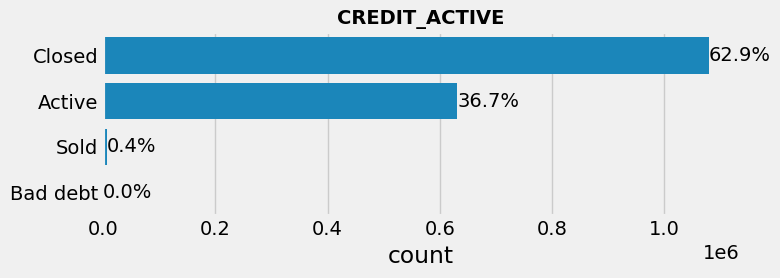

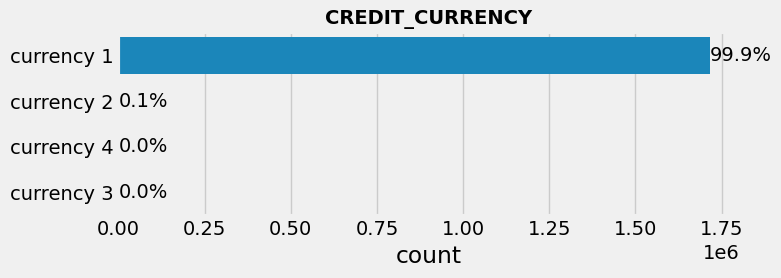

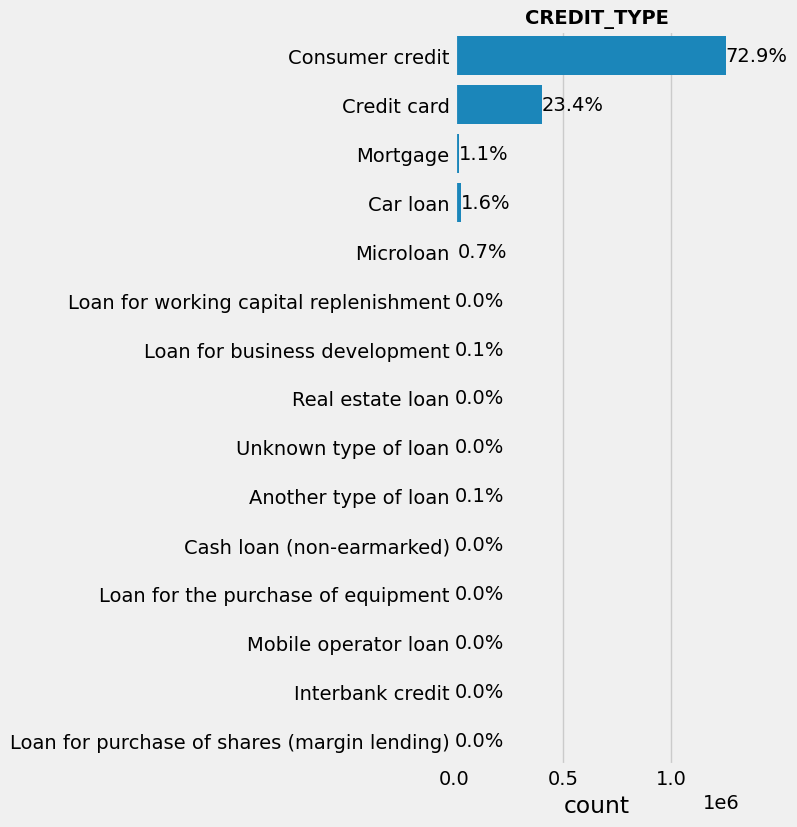

In [6]:
for col in ["CREDIT_ACTIVE", "CREDIT_CURRENCY", "CREDIT_TYPE"]:
    plot_categorical_dist(bureau, col)

* **For ["CREDIT_ACTIVE", "CREDIT_CURRENCY", "CREDIT_TYPE"] majority of groups are too infrequent to be truly meaninful**

!Servere outliers detected. Total values: 1716428 original range: 0.0 - 585000000.0
Hiding outliers above 3358125.0: 20575 values;


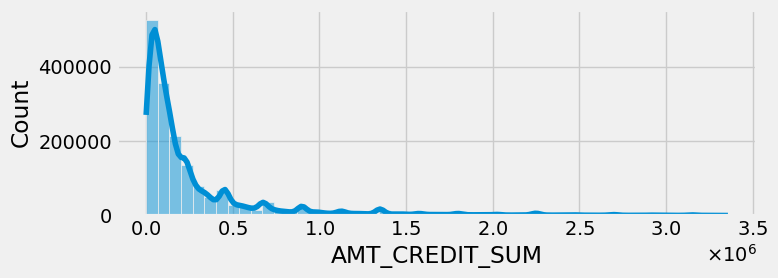

!Servere outliers detected. Total values: 1716428 original range: -586406.115 - 4705600.32
Hiding outliers bellow -8604.10012499993: 106 values;
Hiding outliers above 14340.166874999883: 47667 values;


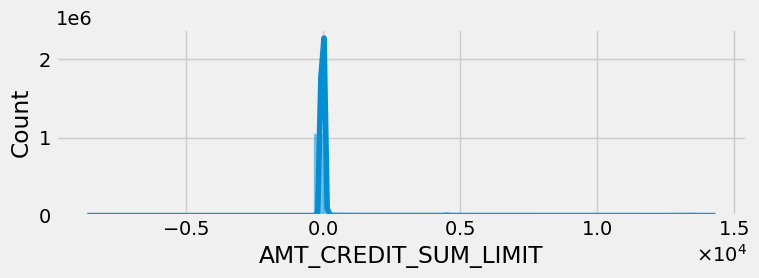

!Servere outliers detected. Total values: 1716428 original range: 0.0 - 118453423.5
Hiding outliers above 116428.49999999948: 5035 values;


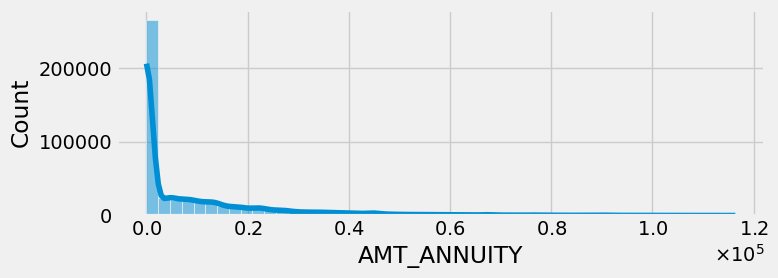

In [7]:
for col in [
    "AMT_CREDIT_SUM",
    "AMT_CREDIT_SUM_LIMIT",
    "AMT_ANNUITY",
]:
    cleaner_helper.plot_numeric_dist(bureau, col)


* Postive and negative credit can be owned (overpaying)
* Majority of people have a credit balance of 0

#### Overdue credit

In [8]:
bureau_overdue =["AMT_CREDIT_SUM_DEBT", 'CREDIT_DAY_OVERDUE', 'AMT_CREDIT_MAX_OVERDUE', 'AMT_CREDIT_SUM_OVERDUE', ]

tables_columns['bureau_overdue'] = bureau_overdue
num_columns.update(bureau_overdue)

describer.describe(bureau_overdue)

from tables:  ['bureau']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
127,CREDIT_DAY_OVERDUE,Number of days past due on CB credit at the time of application for related loan in our sample,NaN,0,942,int64,"[0, 2603, 6]"
130,AMT_CREDIT_MAX_OVERDUE,Maximal amount overdue on the Credit Bureau credit so far (at application date of loan in our sample),NaN,1124488,68251,float64,"[77674.5, 0.0, 14985.0]"
133,AMT_CREDIT_SUM_DEBT,Current debt on Credit Bureau credit,NaN,257669,226537,float64,"[0.0, 171342.0, 71017.38]"
135,AMT_CREDIT_SUM_OVERDUE,Current amount overdue on Credit Bureau credit,NaN,0,1616,float64,"[0.0, 231.525, 288.0]"


* Significant portion of overdue inforation is missing.

!Servere outliers detected. Total values: 1716428 original range: -4705600.32 - 170100000.0
Hiding outliers bellow -943353.6749999991: 12 values;
Hiding outliers above 1572256.1249999986: 24065 values;


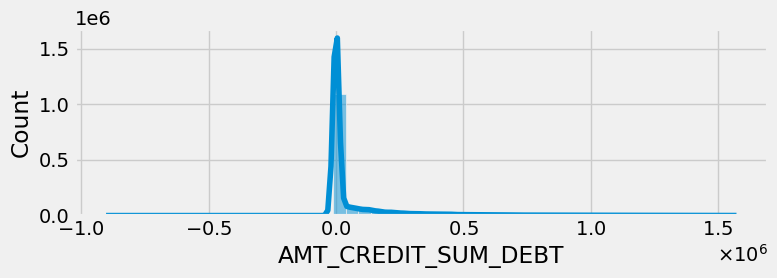

!Warning: low and high bounds are equal. This may indicate a constant or nearly constant series.


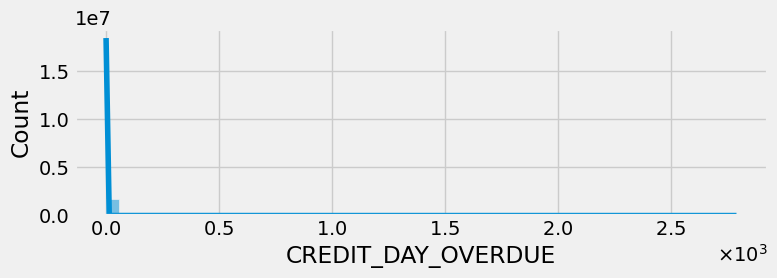

!Servere outliers detected. Total values: 1716428 original range: 0.0 - 115987185.0
Hiding outliers above 35551.13062499999: 7894 values;


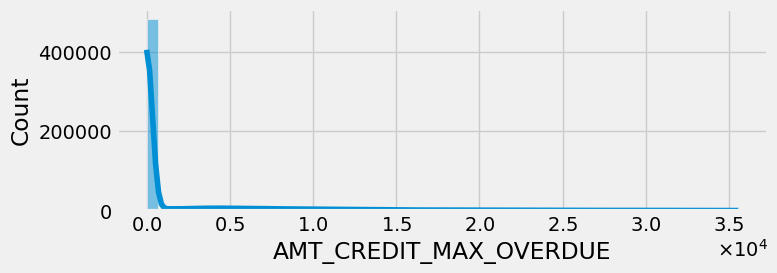

!Warning: low and high bounds are equal. This may indicate a constant or nearly constant series.


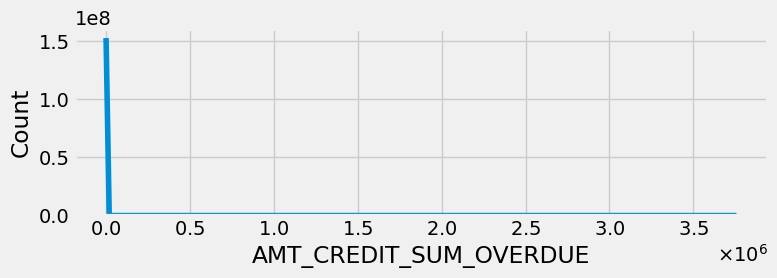

In [9]:
for col in bureau_overdue:
    plot_numeric_dist(bureau, col)

#### Time variables

In [10]:
time_variables = [
    'DAYS_CREDIT', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT',
    'DAYS_CREDIT_UPDATE'
]

tables_columns['time_variables'] = time_variables
num_columns.update(time_variables)


describer.describe(time_variables)

from tables:  ['bureau']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
126,DAYS_CREDIT,How many days before current application did client apply for Credit Bureau credit,time only relative to the application,0,2923,int64,"[-497, -208, -203]"
128,DAYS_CREDIT_ENDDATE,Remaining duration of CB credit (in days) at the time of application in Home Credit,time only relative to the application,105553,14096,float64,"[-153.0, 1075.0, 528.0]"
129,DAYS_ENDDATE_FACT,Days since CB credit ended at the time of application in Home Credit (only for closed credit),time only relative to the application,633653,2917,float64,"[-153.0, -1710.0, -840.0]"
137,DAYS_CREDIT_UPDATE,How many days before loan application did last information about the Credit Bureau credit come,time only relative to the application,0,2982,int64,"[-131, -20, -16]"


* Significant portion of endatates are missing. It is very likely that **people who never took out credit are treated as nan**.
    * 

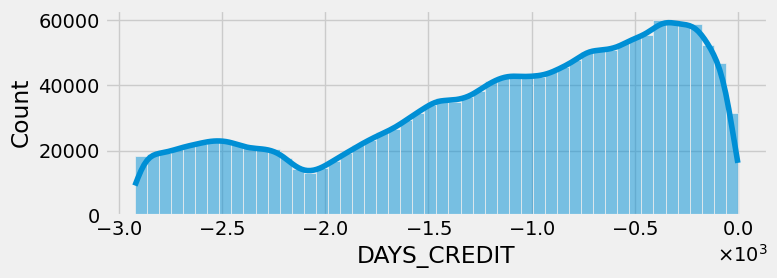

!Servere outliers detected. Total values: 1716428 original range: -42060.0 - 31199.0
Hiding outliers bellow -9589.5: 146 values;
Hiding outliers above 9950.5: 52544 values;


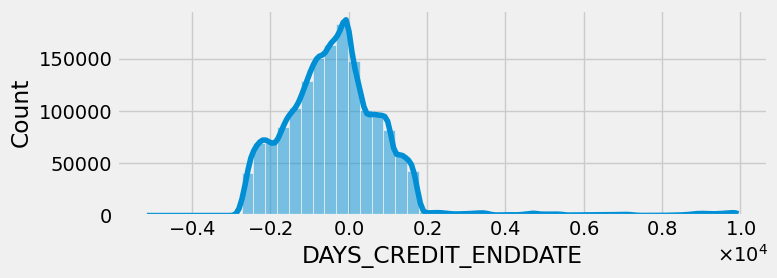

!Servere outliers detected. Total values: 1716428 original range: -42023.0 - 0.0
Hiding outliers bellow -5841.5: 1 values;


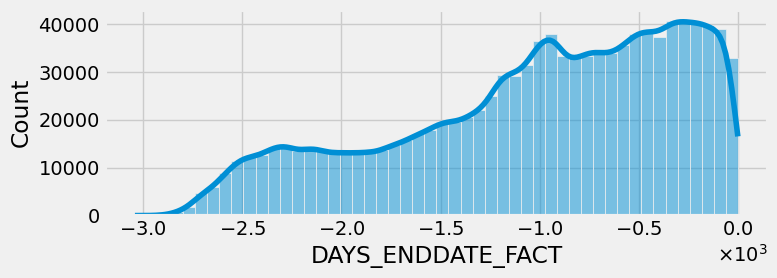

!Servere outliers detected. Total values: 1716428 original range: -41947 - 372
Hiding outliers bellow -5185.5: 95 values;


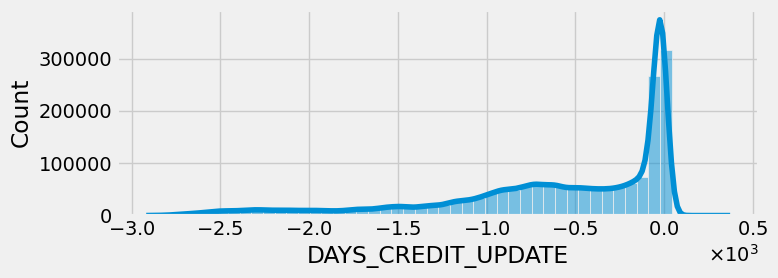

In [11]:
for col in time_variables:
    plot_numeric_dist(bureau, col)

## Bureau Conclusions

In [12]:
tables_columns['bureau'] = list(bureau.columns)

* **Aggregation techniques will be required to engineer useful features from the bureau**.

# bureau_balance

In [13]:
bureau_balance = tables['bureau_balance']
describer = table_navigator.ColumnDescriber(tables, 'bureau_balance')
expected_values = bureau_balance.shape[0]
bureau_balance.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB


In [14]:
bureau_balance.head(5)

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


The data is very narrow and very long. Aggregation will be required for final model, for each individual.

In [15]:
bureau_balance_all = ['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']

tables_columns['bureau_balance'] = bureau_balance_all
id_variables.add('SK_ID_BUREAU')
cat_columns.add('STATUS')
num_columns.add('MONTHS_BALANCE')

describer.describe(bureau_balance_all)

from tables:  ['bureau_balance']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
140,MONTHS_BALANCE,Month of balance relative to application date (-1 means the freshest balance date),time only relative to the application,0,97,int64,"[0, -1, -2]"
141,STATUS,"Status of Credit Bureau loan during the month (active, closed, DPD0-30,ï¿½ [C means closed, X means status unknown, 0 means no DPD, 1 means maximal did during month between 1-30, 2 means DPD 31-60,ï¿½ 5 means DPD 120+ or sold or written off ] )",NaN,0,8,object,"[C, 0, X]"


* The bureau table stores encoded evaluation of montly balance. **Significant potential for feature engineering**

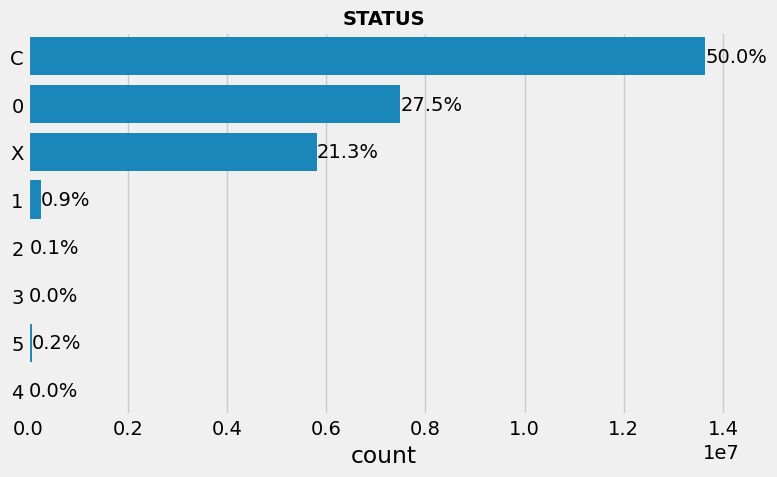

STATUS
C    13646993
0    7499507 
X    5810482 
1    242347  
5    62406   
2    23419   
3    8924    
4    5847    
Name: count, dtype: int64

In [16]:
plot_categorical_dist(bureau_balance, 'STATUS')

Monrths are not plotted due to volume of data.

# POS_CASH_balance

In [17]:
pos_cash_balance = tables['POS_CASH_balance']
describer = table_navigator.ColumnDescriber(tables, 'POS_CASH_balance')
pos_cash_balance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   object 
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 610.4+ MB


In [18]:
pos_cash_balance_all = [
    'SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT',
    'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF'
]

tables_columns['pos_cash_balance'] = pos_cash_balance_all
id_variables.update(['SK_ID_PREV', 'SK_ID_CURR'])
cat_columns.add('NAME_CONTRACT_STATUS')
num_columns.update(['MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'SK_DPD', 'SK_DPD_DEF'])

describer.describe(pos_cash_balance_all)

from tables:  ['POS_CASH_balance']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
143,SK_ID_CURR,ID of loan in our sample,NaN,0,337252,int64,"[182943, 367990, 397406]"
144,MONTHS_BALANCE,"Month of balance relative to application date (-1 means the information to the freshest monthly snapshot, 0 means the information at application - often it will be the same as -1 as many banks are not updating the information to Credit Bureau regularly )",time only relative to the application,0,96,int64,"[-31, -33, -32]"
145,CNT_INSTALMENT,Term of previous credit (can change over time),NaN,26071,73,float64,"[48.0, 36.0, 12.0]"
146,CNT_INSTALMENT_FUTURE,Installments left to pay on the previous credit,NaN,26087,79,float64,"[45.0, 35.0, 9.0]"
147,NAME_CONTRACT_STATUS,Contract status during the month,NaN,0,9,object,"[Active, Completed, Signed]"
148,SK_DPD,DPD (days past due) during the month of previous credit,NaN,0,3400,int64,"[0, 1, 2]"
149,SK_DPD_DEF,DPD during the month with tolerance (debts with low loan amounts are ignored) of the previous credit,NaN,0,2307,int64,"[0, 1, 2]"


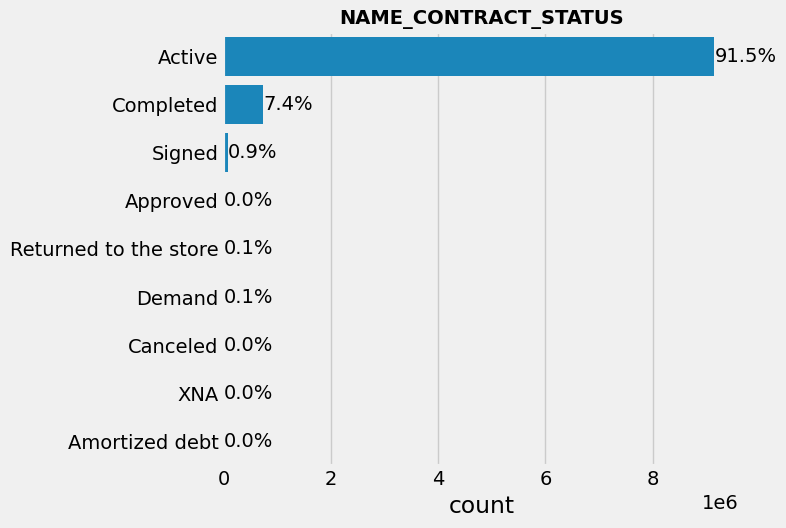

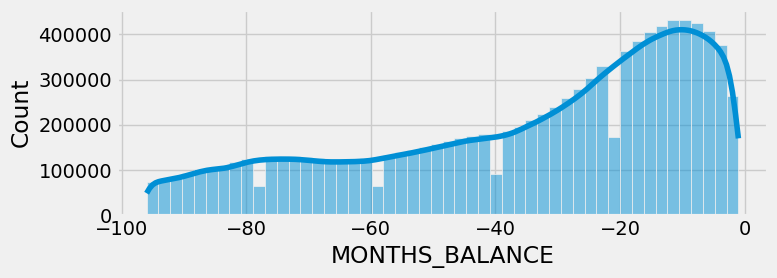

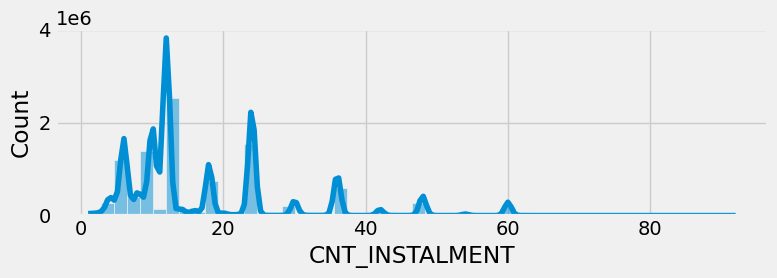

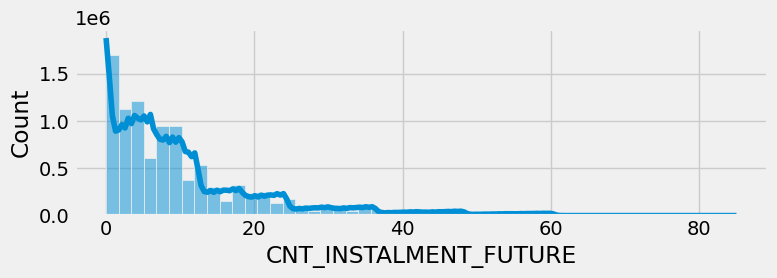

!Warning: low and high bounds are equal. This may indicate a constant or nearly constant series.


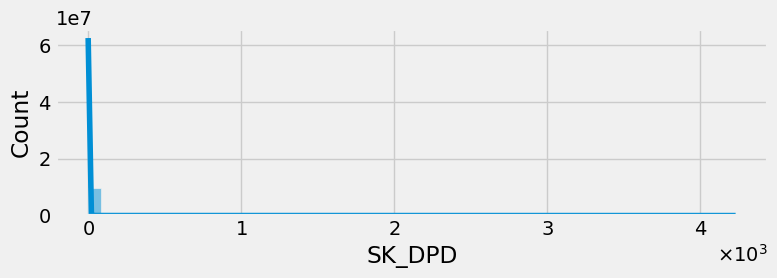

!Warning: low and high bounds are equal. This may indicate a constant or nearly constant series.


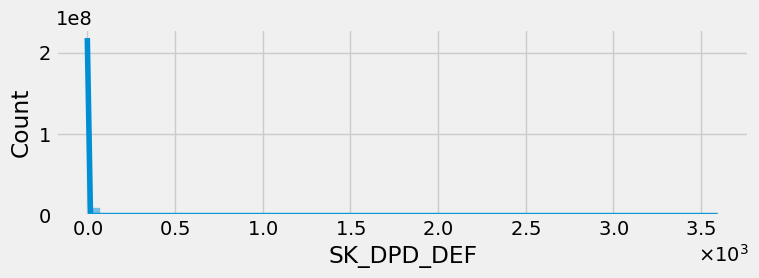

In [19]:
plot_categorical_dist(pos_cash_balance, 'NAME_CONTRACT_STATUS')

for col in ['MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'SK_DPD', 'SK_DPD_DEF']:
    plot_numeric_dist(pos_cash_balance, col)

# credit_card_balance

In [20]:
credit_card_balance = tables['credit_card_balance']
describer = table_navigator.ColumnDescriber(tables, 'credit_card_balance')
credit_card_balance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  CNT_INSTALMENT_MATURE

* Credit card balance provides data that is **both wide and longer than applications table. Prime target for Unsupervised learning style feature engineering**

#### Balance and limits

In [21]:
balance_limits = [
    "SK_ID_PREV",
    "SK_ID_CURR",
    "MONTHS_BALANCE",
    "AMT_BALANCE",
    "AMT_CREDIT_LIMIT_ACTUAL",
    "AMT_RECEIVABLE_PRINCIPAL",
    "AMT_RECIVABLE",
    "AMT_TOTAL_RECEIVABLE",
]

tables_columns["balance_limits"] = balance_limits
id_variables.update(["SK_ID_PREV", "SK_ID_CURR"])
num_columns.update(
    [
        "MONTHS_BALANCE",
        "AMT_BALANCE",
        "AMT_CREDIT_LIMIT_ACTUAL",
        "AMT_RECEIVABLE_PRINCIPAL",
        "AMT_RECIVABLE",
        "AMT_TOTAL_RECEIVABLE",
    ]
)

describer.describe(balance_limits)

from tables:  ['credit_card_balance']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
151,SK_ID_CURR,ID of loan in our sample,hashed,0,103558,int64,"[378907, 363914, 371185]"
152,MONTHS_BALANCE,Month of balance relative to application date (-1 means the freshest balance date),time only relative to the application,0,96,int64,"[-6, -1, -7]"
153,AMT_BALANCE,Balance during the month of previous credit,NaN,0,1347904,float64,"[56.97, 63975.555, 31815.225]"
154,AMT_CREDIT_LIMIT_ACTUAL,Credit card limit during the month of the previous credit,NaN,0,181,int64,"[135000, 45000, 450000]"
162,AMT_RECEIVABLE_PRINCIPAL,Amount receivable for principal on the previous credit,NaN,0,1195839,float64,"[0.0, 60175.08, 26926.425]"
163,AMT_RECIVABLE,Amount receivable on the previous credit,NaN,0,1338878,float64,"[0.0, 64875.555, 31460.085]"
164,AMT_TOTAL_RECEIVABLE,Total amount receivable on the previous credit,NaN,0,1339008,float64,"[0.0, 64875.555, 31460.085]"


* No missing values greatly simplifies analysis.
* credit_card_balance stored as discrete values

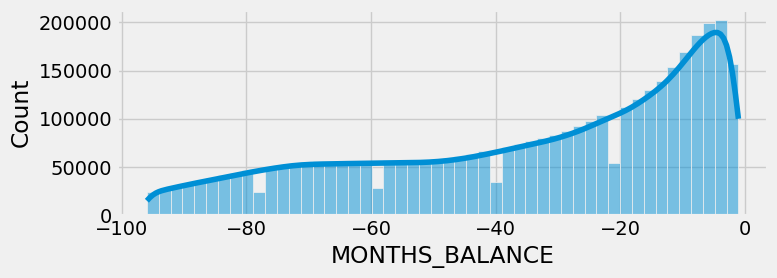

!Servere outliers detected. Total values: 3840312 original range: -420250.185 - 1505902.185
Hiding outliers bellow -385772.06812499976: 1 values;
Hiding outliers above 642953.4468749996: 15770 values;


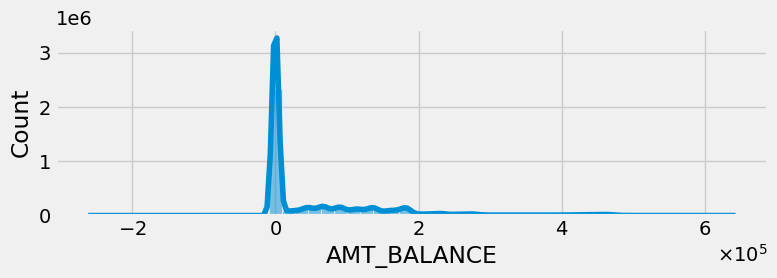

!Servere outliers detected. Total values: 3840312 original range: 0 - 1350000
Hiding outliers above 1125000.0: 191 values;


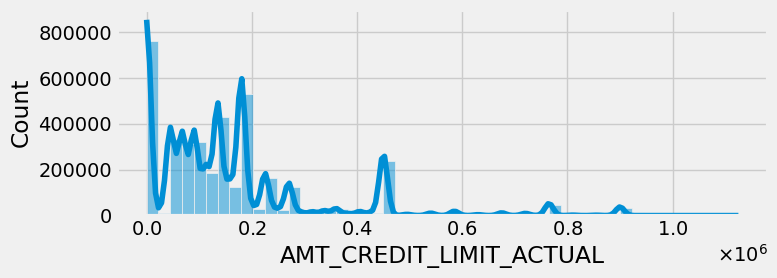

!Servere outliers detected. Total values: 3840312 original range: -423305.82 - 1472316.795
Hiding outliers bellow -371705.12212499965: 1 values;
Hiding outliers above 619508.5368749994: 16038 values;


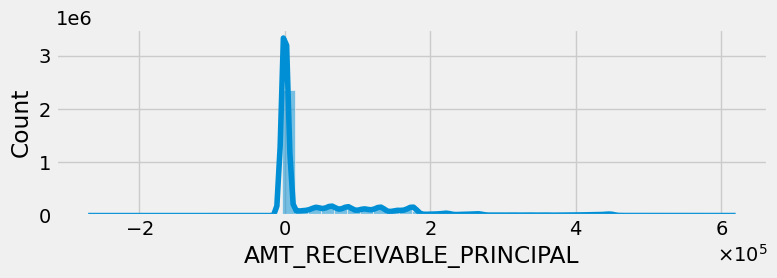

!Servere outliers detected. Total values: 3840312 original range: -420250.185 - 1493338.185
Hiding outliers bellow -384668.12249999924: 1 values;
Hiding outliers above 641113.5374999987: 15708 values;


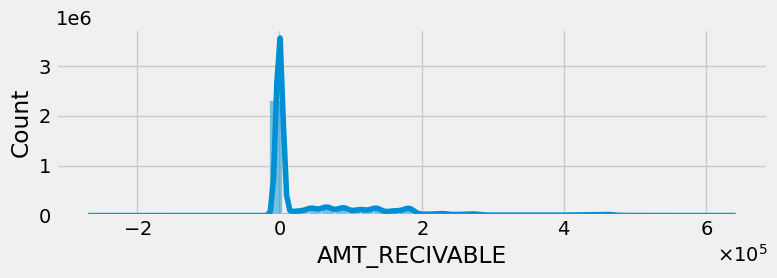

!Servere outliers detected. Total values: 3840312 original range: -420250.185 - 1493338.185
Hiding outliers bellow -384702.75: 1 values;
Hiding outliers above 641171.25: 15702 values;


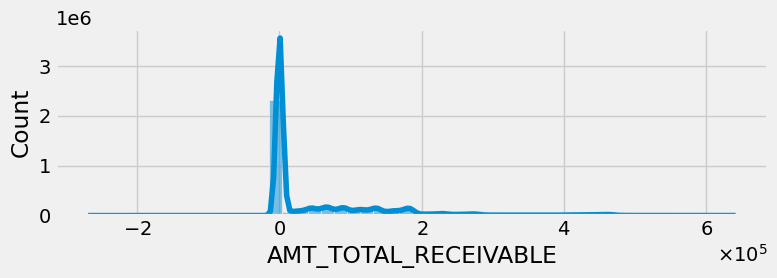

In [22]:
for col in ['MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE']:
    plot_numeric_dist(credit_card_balance, col)

* 0 values dominate the balance values, with significant variables. **linear methods with squared loss fucntions should be avoided**

#### Drawings and payments

In [23]:
drawings_payments = [
    'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT',
    'AMT_DRAWINGS_POS_CURRENT', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT',
    'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT',
    'CNT_DRAWINGS_POS_CURRENT'
]

tables_columns['drawings_payments'] = drawings_payments
num_columns.update(drawings_payments)

describer.describe(drawings_payments)

from tables:  ['credit_card_balance']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
155,AMT_DRAWINGS_ATM_CURRENT,Amount drawing at ATM during the month of the previous credit,NaN,749816,2267,float64,"[0.0, 2250.0, 67500.0]"
156,AMT_DRAWINGS_CURRENT,Amount drawing during the month of the previous credit,NaN,0,187005,float64,"[877.5, 2250.0, 0.0]"
157,AMT_DRAWINGS_OTHER_CURRENT,Amount of other drawings during the month of the previous credit,NaN,749816,1832,float64,"[0.0, 137700.0, 177840.0]"
158,AMT_DRAWINGS_POS_CURRENT,Amount drawing or buying goods during the month of the previous credit,NaN,749816,168748,float64,"[877.5, 0.0, 11547.0]"
160,AMT_PAYMENT_CURRENT,How much did the client pay during the month on the previous credit,NaN,767988,163209,float64,"[1800.0, 2250.0, 11925.0]"
161,AMT_PAYMENT_TOTAL_CURRENT,How much did the client pay during the month in total on the previous credit,NaN,0,182957,float64,"[1800.0, 2250.0, 11925.0]"
165,CNT_DRAWINGS_ATM_CURRENT,Number of drawings at ATM during this month on the previous credit,NaN,749816,44,float64,"[0.0, 1.0, 3.0]"
166,CNT_DRAWINGS_CURRENT,Number of drawings during this month on the previous credit,NaN,0,129,int64,"[1, 0, 8]"
167,CNT_DRAWINGS_OTHER_CURRENT,Number of other drawings during this month on the previous credit,NaN,749816,11,float64,"[0.0, 1.0, 3.0]"
168,CNT_DRAWINGS_POS_CURRENT,Number of drawings for goods during this month on the previous credit,NaN,749816,133,float64,"[1.0, 0.0, 5.0]"


* **Origin of ATM and drawing value NANs, should be investigated**.

In [24]:
credit_card_balance.loc[credit_card_balance['AMT_DRAWINGS_ATM_CURRENT'].isna(), :]

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
45,2657726,399970,-5,0.0,225000,NaN,0.0,NaN,NaN,0.0,...,0.0,0.0,NaN,0,NaN,NaN,0.0,Active,0,0
47,1517613,121258,-6,0.0,135000,NaN,0.0,NaN,NaN,0.0,...,0.0,0.0,NaN,0,NaN,NaN,0.0,Active,0,0
49,2408643,104761,-4,0.0,225000,NaN,0.0,NaN,NaN,0.0,...,0.0,0.0,NaN,0,NaN,NaN,0.0,Active,0,0
52,1322825,215709,-5,0.0,180000,NaN,0.0,NaN,NaN,0.0,...,0.0,0.0,NaN,0,NaN,NaN,0.0,Active,0,0
60,1217908,162464,-5,0.0,45000,NaN,0.0,NaN,NaN,0.0,...,0.0,0.0,NaN,0,NaN,NaN,0.0,Active,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3840272,2463643,315621,-15,0.0,0,NaN,0.0,NaN,NaN,0.0,...,0.0,0.0,NaN,0,NaN,NaN,0.0,Active,0,0
3840303,1307188,385981,-9,0.0,0,NaN,0.0,NaN,NaN,0.0,...,0.0,0.0,NaN,0,NaN,NaN,0.0,Active,0,0
3840306,1410474,255737,-13,0.0,180000,NaN,0.0,NaN,NaN,0.0,...,0.0,0.0,NaN,0,NaN,NaN,0.0,Active,0,0
3840307,1036507,328243,-9,0.0,45000,NaN,0.0,NaN,NaN,0.0,...,0.0,0.0,NaN,0,NaN,NaN,0.0,Active,0,0


This information cannot be derived frm current table, origins likely lie in person having or not having a credit card.

!Servere outliers detected. Total values: 3840312 original range: -6827.31 - 2115000.0
Hiding outliers above 84375.0: 70853 values;


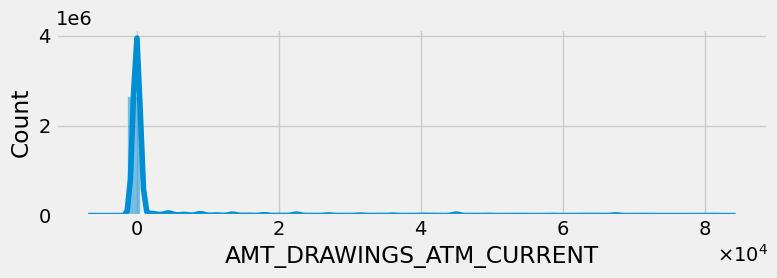

!Servere outliers detected. Total values: 3840312 original range: -6211.62 - 2287098.315
Hiding outliers above 112500.0: 68928 values;


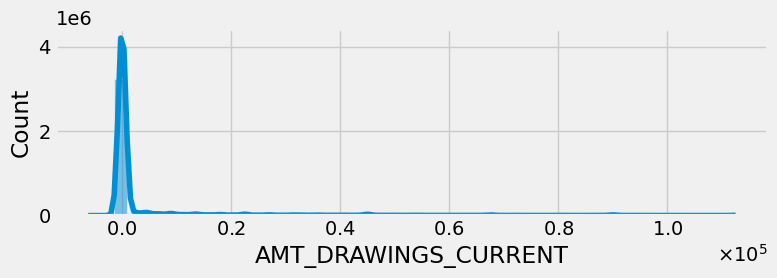

!Warning: low and high bounds are equal. This may indicate a constant or nearly constant series.


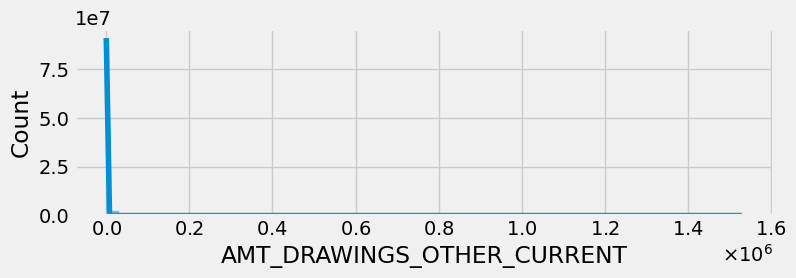

!Servere outliers detected. Total values: 3840312 original range: 0.0 - 2239274.16
Hiding outliers above 25290.0: 94210 values;


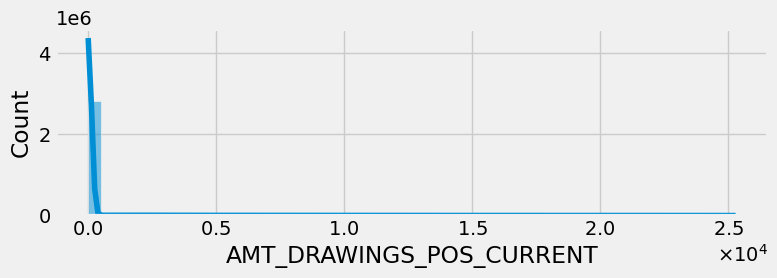

!Servere outliers detected. Total values: 3840312 original range: 0.0 - 4289207.445
Hiding outliers above 78750.0: 63241 values;


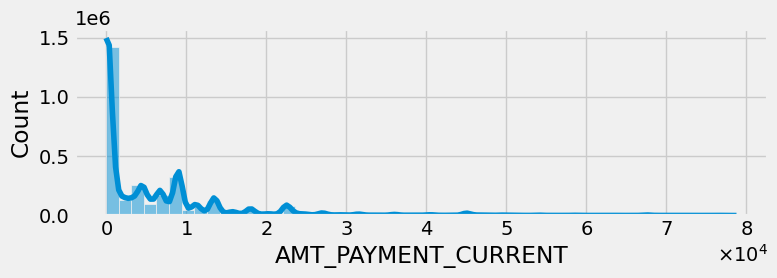

!Servere outliers detected. Total values: 3840312 original range: 0.0 - 4278315.69
Hiding outliers above 58500.0: 78143 values;


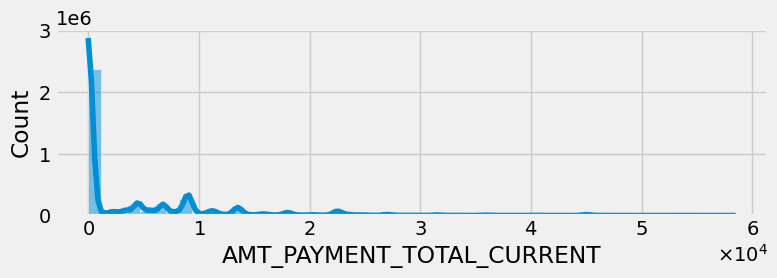

!Servere outliers detected. Total values: 3840312 original range: 0.0 - 51.0
Hiding outliers above 5.0: 27696 values;


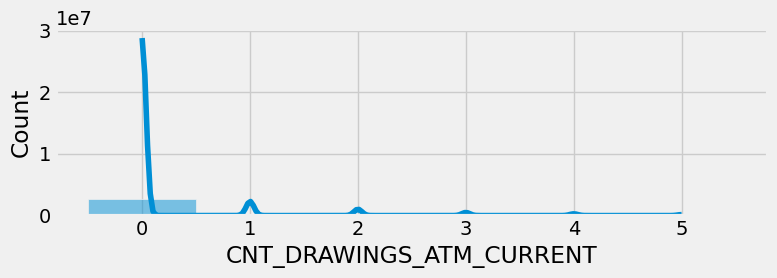

!Servere outliers detected. Total values: 3840312 original range: 0 - 165
Hiding outliers above 10.0: 58069 values;


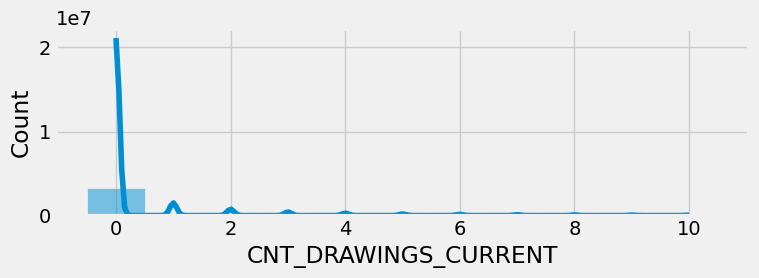

!Warning: low and high bounds are equal. This may indicate a constant or nearly constant series.


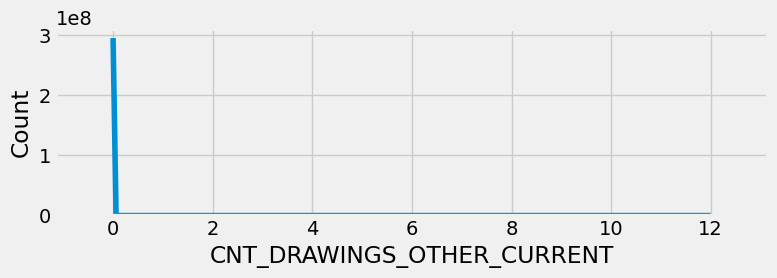

!Servere outliers detected. Total values: 3840312 original range: 0.0 - 165.0
Hiding outliers above 5.0: 88866 values;


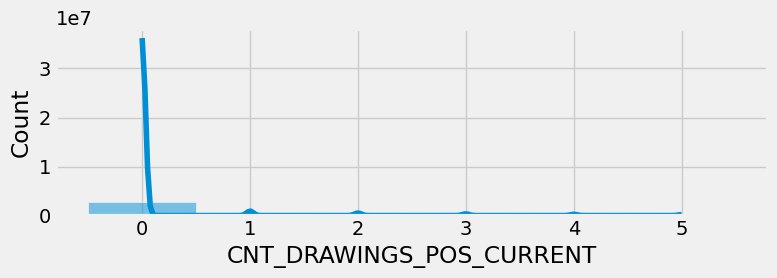

In [25]:
for col in drawings_payments:
    plot_numeric_dist(credit_card_balance, col)

#### Contract status and installments

In [26]:
contract_installments = [
    'NAME_CONTRACT_STATUS', 'AMT_INST_MIN_REGULARITY', 'CNT_INSTALMENT_MATURE_CUM',
    'SK_DPD', 'SK_DPD_DEF'
]

tables_columns['contract_installments'] = contract_installments
cat_columns.add('NAME_CONTRACT_STATUS')
num_columns.update(['AMT_INST_MIN_REGULARITY', 'CNT_INSTALMENT_MATURE_CUM', 'SK_DPD', 'SK_DPD_DEF'])

describer.describe(contract_installments)

from tables:  ['credit_card_balance']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
159,AMT_INST_MIN_REGULARITY,Minimal installment for this month of the previous credit,NaN,305236,312266,float64,"[1700.325, 2250.0, 11795.76]"
169,CNT_INSTALMENT_MATURE_CUM,Number of paid installments on the previous credit,NaN,305236,121,float64,"[35.0, 69.0, 30.0]"
170,NAME_CONTRACT_STATUS,"Contract status (active signed,...) on the previous credit",NaN,0,7,object,"[Active, Completed, Demand]"
171,SK_DPD,DPD (Days past due) during the month on the previous credit,NaN,0,917,int64,"[0, 7, 2192]"
172,SK_DPD_DEF,DPD (Days past due) during the month with tolerance (debts with low loan amounts are ignored) of the previous credit,NaN,0,378,int64,"[0, 7, 99]"


* Previous credit installment values are likely missing if previous credit was not made.

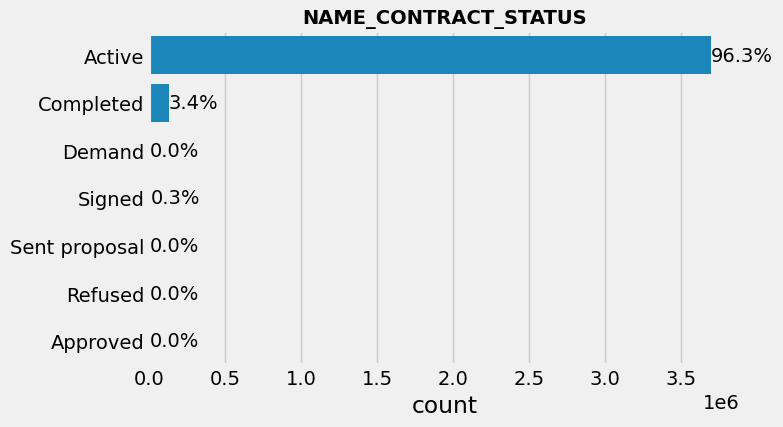

!Servere outliers detected. Total values: 3840312 original range: 0.0 - 202882.005
Hiding outliers above 33750.0: 12997 values;


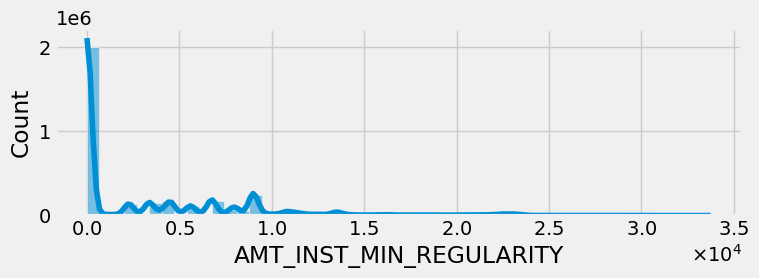

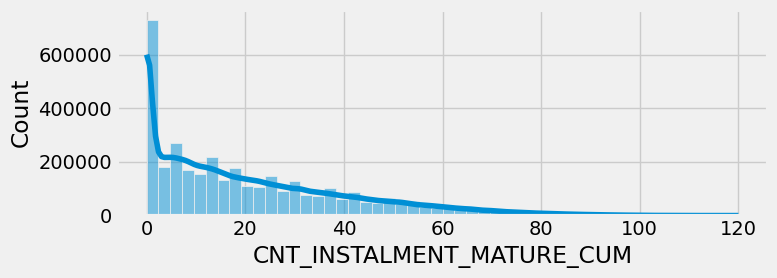

!Warning: low and high bounds are equal. This may indicate a constant or nearly constant series.


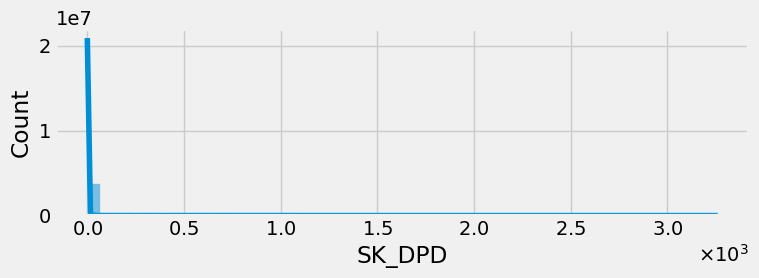

!Warning: low and high bounds are equal. This may indicate a constant or nearly constant series.


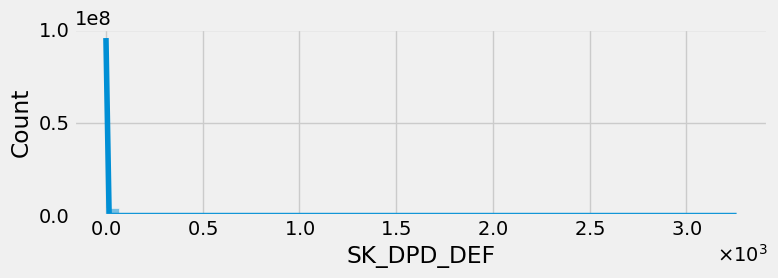

In [27]:
for col in contract_installments:
    if credit_card_balance[col].dtype == 'object':
        plot_categorical_dist(credit_card_balance, col)
    else:
        plot_numeric_dist(credit_card_balance, col)

* NAME_CONTRACT__STATUS is highly imbalanced.

## credit_card_balance Conclusions

In [28]:
tables_columns['credit_card_balance'] = list(credit_card_balance.columns)

# previous_application

In [29]:
previous_application = tables['previous_application']
describer = table_navigator.ColumnDescriber(tables, 'previous_application')
previous_application_dict ={}
display(previous_application.shape)
expected_values = previous_application.shape[0]

(1670214, 37)

#### Application basics

In [30]:
application_basics = [
    'SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION',
    'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START',
    'HOUR_APPR_PROCESS_START'
]

previous_application_dict['application_basics'] = application_basics
id_variables.update(['SK_ID_PREV', 'SK_ID_CURR'])
cat_columns.update(['NAME_CONTRACT_TYPE', 'WEEKDAY_APPR_PROCESS_START'])
num_columns.update(['AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'HOUR_APPR_PROCESS_START'])

describer.describe(application_basics)

from tables:  ['previous_application']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
174,SK_ID_CURR,ID of loan in our sample,hashed,0,338857,int64,"[271877, 108129, 122040]"
175,NAME_CONTRACT_TYPE,"Contract product type (Cash loan, consumer loan [POS] ,...) of the previous application",NaN,0,4,object,"[Consumer loans, Cash loans, Revolving loans]"
176,AMT_ANNUITY,Annuity of previous application,NaN,372235,357959,float64,"[1730.43, 25188.615, 15060.735]"
177,AMT_APPLICATION,For how much credit did client ask on the previous application,NaN,0,93885,float64,"[17145.0, 607500.0, 112500.0]"
178,AMT_CREDIT,"Final credit amount on the previous application. This differs from AMT_APPLICATION in a way that the AMT_APPLICATION is the amount for which the client initially applied for, but during our approval process he could have received different amount - AMT_CREDIT",NaN,1,86803,float64,"[17145.0, 679671.0, 136444.5]"
179,AMT_DOWN_PAYMENT,Down payment on the previous application,NaN,895844,29278,float64,"[0.0, 12649.5, 1350.0]"
180,AMT_GOODS_PRICE,Goods price of good that client asked for (if applicable) on the previous application,NaN,385515,93885,float64,"[17145.0, 607500.0, 112500.0]"
181,WEEKDAY_APPR_PROCESS_START,On which day of the week did the client apply for previous application,NaN,0,7,object,"[SATURDAY, THURSDAY, TUESDAY]"
182,HOUR_APPR_PROCESS_START,Approximately at what day hour did the client apply for the previous application,rounded,0,24,int64,"[15, 11, 7]"


* Previous appplication info is missing, if previous paplication was not made.

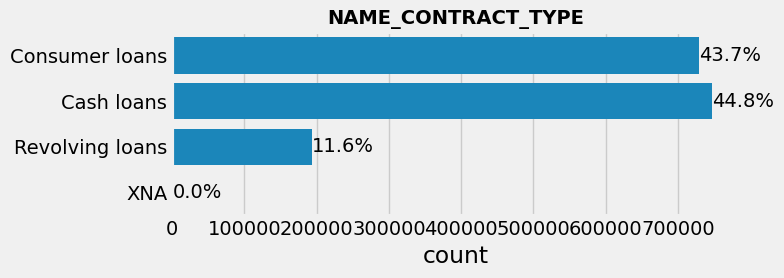

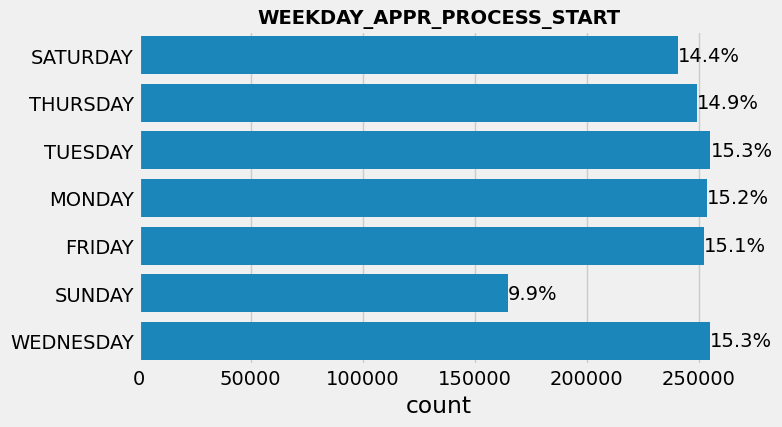

!Servere outliers detected. Total values: 1670214 original range: 0.0 - 418058.145
Hiding outliers above 109252.0575: 2104 values;


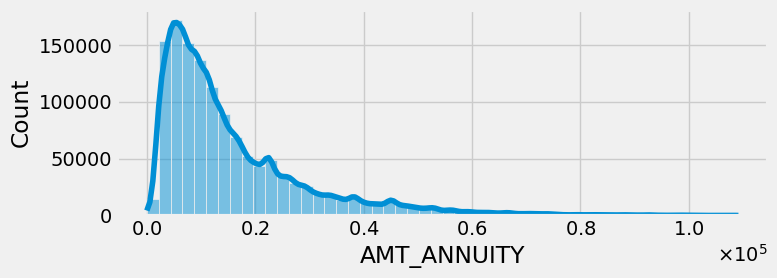

!Servere outliers detected. Total values: 1670214 original range: 0.0 - 6905160.0
Hiding outliers above 1968750.0: 4843 values;


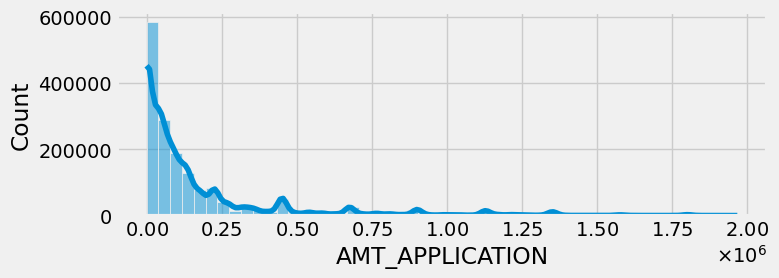

!Servere outliers detected. Total values: 1670214 original range: 0.0 - 6905160.0
Hiding outliers above 2216250.0: 4126 values;


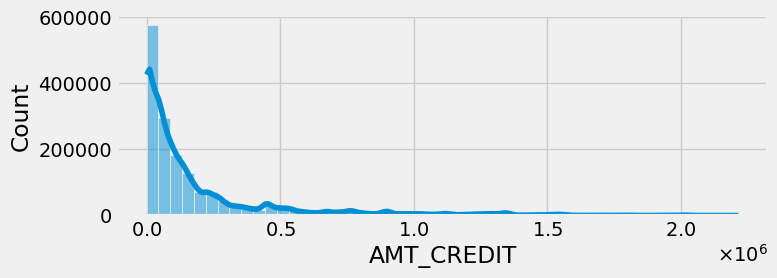

!Servere outliers detected. Total values: 1670214 original range: -0.9 - 3060045.0
Hiding outliers above 65460.20624999944: 7794 values;


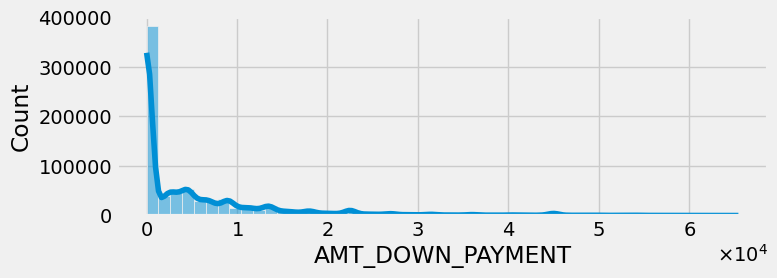

!Servere outliers detected. Total values: 1670214 original range: 0.0 - 6905160.0
Hiding outliers above 2215676.25: 3109 values;


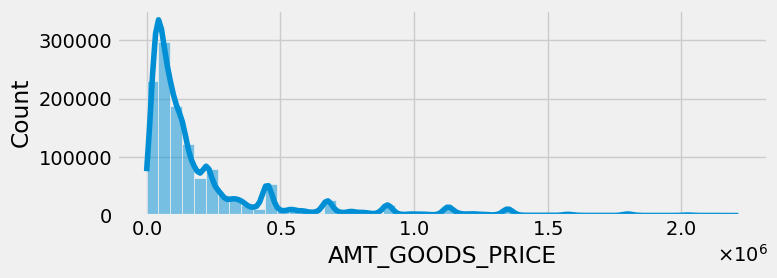

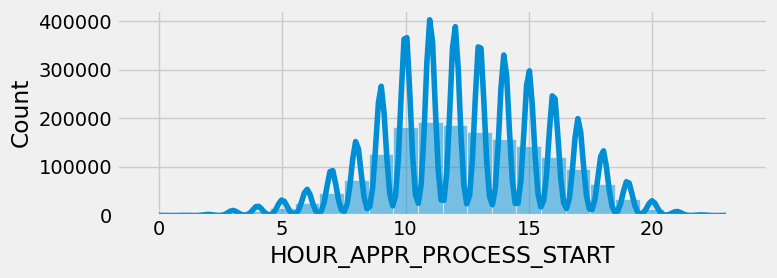

In [31]:
for col in ['NAME_CONTRACT_TYPE', 'WEEKDAY_APPR_PROCESS_START']:
    plot_categorical_dist(previous_application, col)

for col in ['AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'HOUR_APPR_PROCESS_START']:
    plot_numeric_dist(previous_application, col)

* **Most of previous applicaiton variables correspond to the actual application features**.

#### Application status and rates

In [32]:
application_status_rates = [
    'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT',
    'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE',
    'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON'
]

previous_application_dict['application_status_rates'] = application_status_rates
bool_columns.update(['FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY'])
cat_columns.update(['NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON'])
num_columns.update(['RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'DAYS_DECISION'])

describer.describe(application_status_rates)

from tables:  ['previous_application']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
183,FLAG_LAST_APPL_PER_CONTRACT,Flag if it was last application for the previous contract. Sometimes by mistake of client or our clerk there could be more applications for one single contract,NaN,0,2,object,"[Y, N]"
184,NFLAG_LAST_APPL_IN_DAY,Flag if the application was the last application per day of the client. Sometimes clients apply for more applications a day. Rarely it could also be error in our system that one application is in the database twice,NaN,0,2,int64,"[1, 0]"
186,RATE_DOWN_PAYMENT,Down payment rate normalized on previous credit,normalized,895844,207033,float64,"[0.0, 0.1039712869911545, 0.0513237940193642]"
187,RATE_INTEREST_PRIMARY,Interest rate normalized on previous credit,normalized,1664263,148,float64,"[0.1828318032415278, 0.1969143148588915, 0.1891363481808909]"
188,RATE_INTEREST_PRIVILEGED,Interest rate normalized on previous credit,normalized,1664263,25,float64,"[0.8673361522198731, 0.8350951374207188, 0.5687103594080338]"
189,NAME_CASH_LOAN_PURPOSE,Purpose of the cash loan,NaN,0,25,object,"[XAP, XNA, Repairs]"
190,NAME_CONTRACT_STATUS,"Contract status (approved, cancelled, ...) of previous application",NaN,0,4,object,"[Approved, Refused, Canceled]"
191,DAYS_DECISION,Relative to current application when was the decision about previous application made,time only relative to the application,0,2922,int64,"[-73, -164, -301]"
192,NAME_PAYMENT_TYPE,Payment method that client chose to pay for the previous application,NaN,0,4,object,"[Cash through the bank, XNA, Non-cash from your account]"
193,CODE_REJECT_REASON,Why was the previous application rejected,NaN,0,9,object,"[XAP, HC, LIMIT]"


* A lot of previous credit information is missing **non provided or still not started to pay credits might be included**.

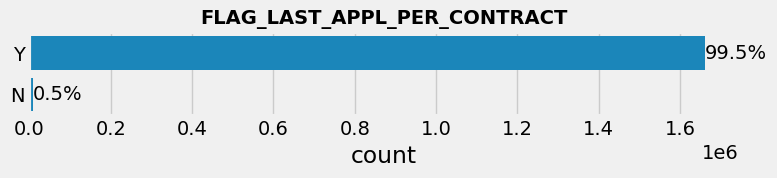

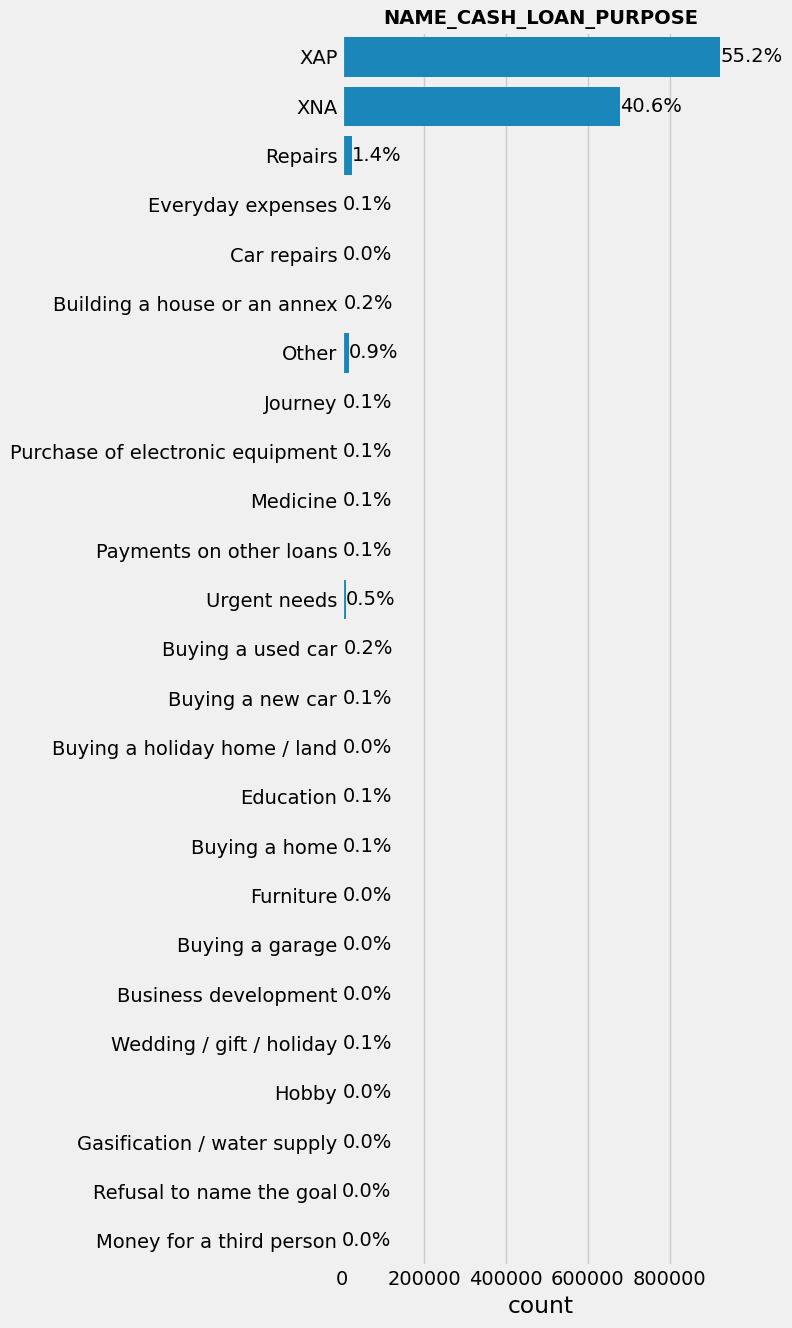

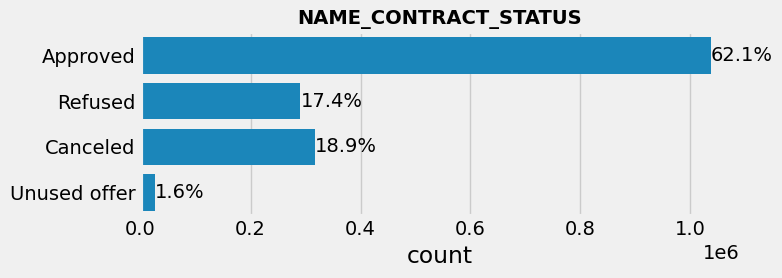

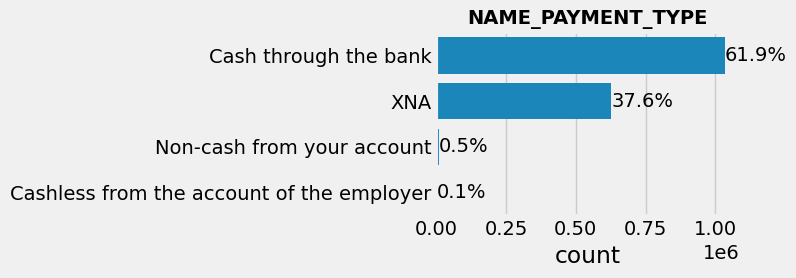

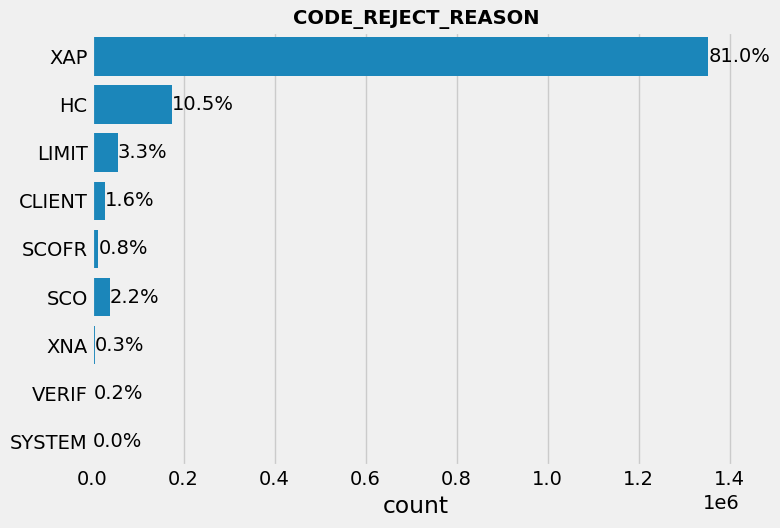

!Warning: low and high bounds are equal. This may indicate a constant or nearly constant series.


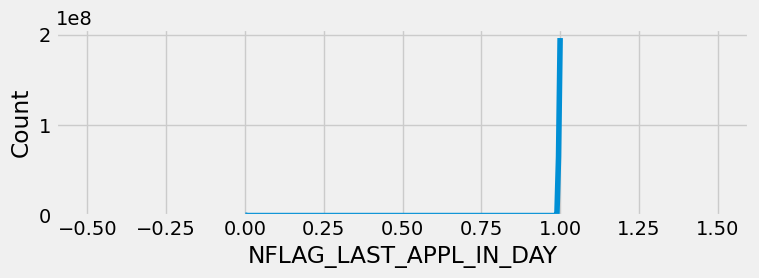

!Servere outliers detected. Total values: 1670214 original range: -1.4978763414307848e-05 - 1.0
Hiding outliers above 0.7353160861771946: 537 values;


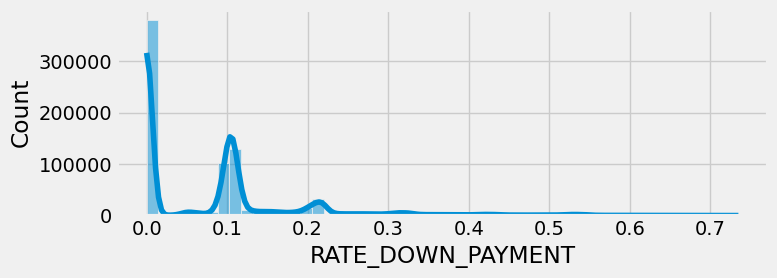

!Servere outliers detected. Total values: 1670214 original range: 0.0347812535418791 - 1.0
Hiding outliers bellow 0.06072906041029126: 66 values;
Hiding outliers above 0.2786254675280516: 163 values;


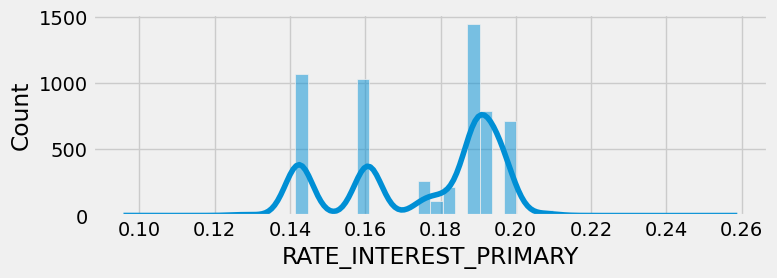

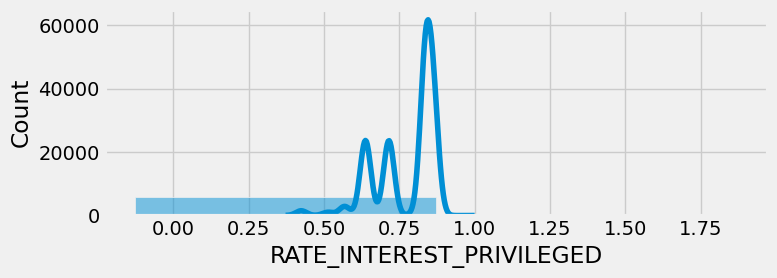

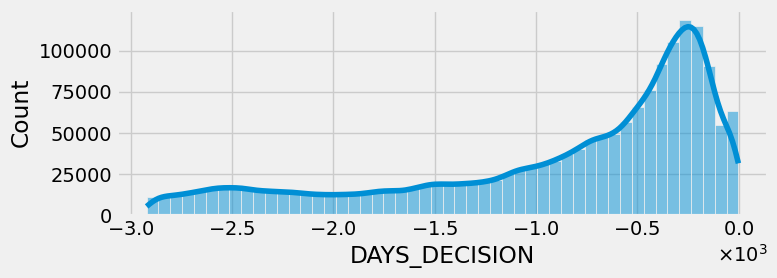

In [33]:
for col in ['FLAG_LAST_APPL_PER_CONTRACT', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON']:
    plot_categorical_dist(previous_application, col)

for col in ['NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'DAYS_DECISION']:
    plot_numeric_dist(previous_application, col)

* **Previous applicaitons could have been for things other than a home loan, consequently this data does not dirrectly carry over**.

#### Client Demographics

#### Client and product information

In [34]:
client_product_info = [
    'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO',
    'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY',
    'CNT_PAYMENT', 'NAME_YIELD_GROUP'
]

previous_application_dict['client_product_info'] = client_product_info
cat_columns.update(['NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'NAME_SELLER_INDUSTRY', 'NAME_YIELD_GROUP'])
num_columns.update(['SELLERPLACE_AREA', 'CNT_PAYMENT'])

describer.describe(client_product_info)

from tables:  ['previous_application']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
194,NAME_TYPE_SUITE,Who accompanied client when applying for the previous application,NaN,820405,7,object,"[Unaccompanied, Spouse, partner, Family]"
195,NAME_CLIENT_TYPE,Was the client old or new client when applying for the previous application,NaN,0,4,object,"[Repeater, New, Refreshed]"
196,NAME_GOODS_CATEGORY,What kind of goods did the client apply for in the previous application,NaN,0,28,object,"[Mobile, XNA, Consumer Electronics]"
197,NAME_PORTFOLIO,"Was the previous application for CASH, POS, CAR, ï¿½",NaN,0,5,object,"[POS, Cash, XNA]"
198,NAME_PRODUCT_TYPE,Was the previous application x-sell o walk-in,NaN,0,3,object,"[XNA, x-sell, walk-in]"
199,CHANNEL_TYPE,Through which channel we acquired the client on the previous application,NaN,0,8,object,"[Country-wide, Contact center, Credit and cash offices]"
200,SELLERPLACE_AREA,Selling area of seller place of the previous application,NaN,0,2097,int64,"[35, -1, 200]"
201,NAME_SELLER_INDUSTRY,The industry of the seller,NaN,0,11,object,"[Connectivity, XNA, Consumer electronics]"
202,CNT_PAYMENT,Term of previous credit at application of the previous application,NaN,372230,49,float64,"[12.0, 36.0, 24.0]"
203,NAME_YIELD_GROUP,Grouped interest rate into small medium and high of the previous application,grouped,0,5,object,"[middle, low_action, high]"


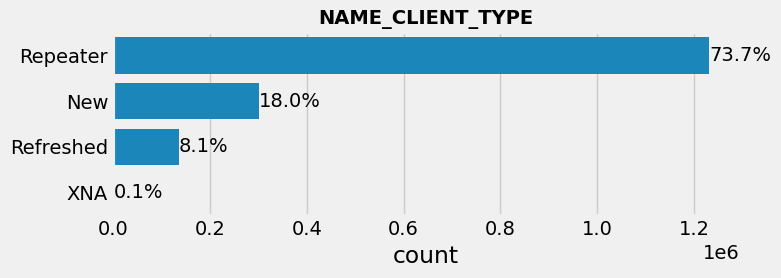

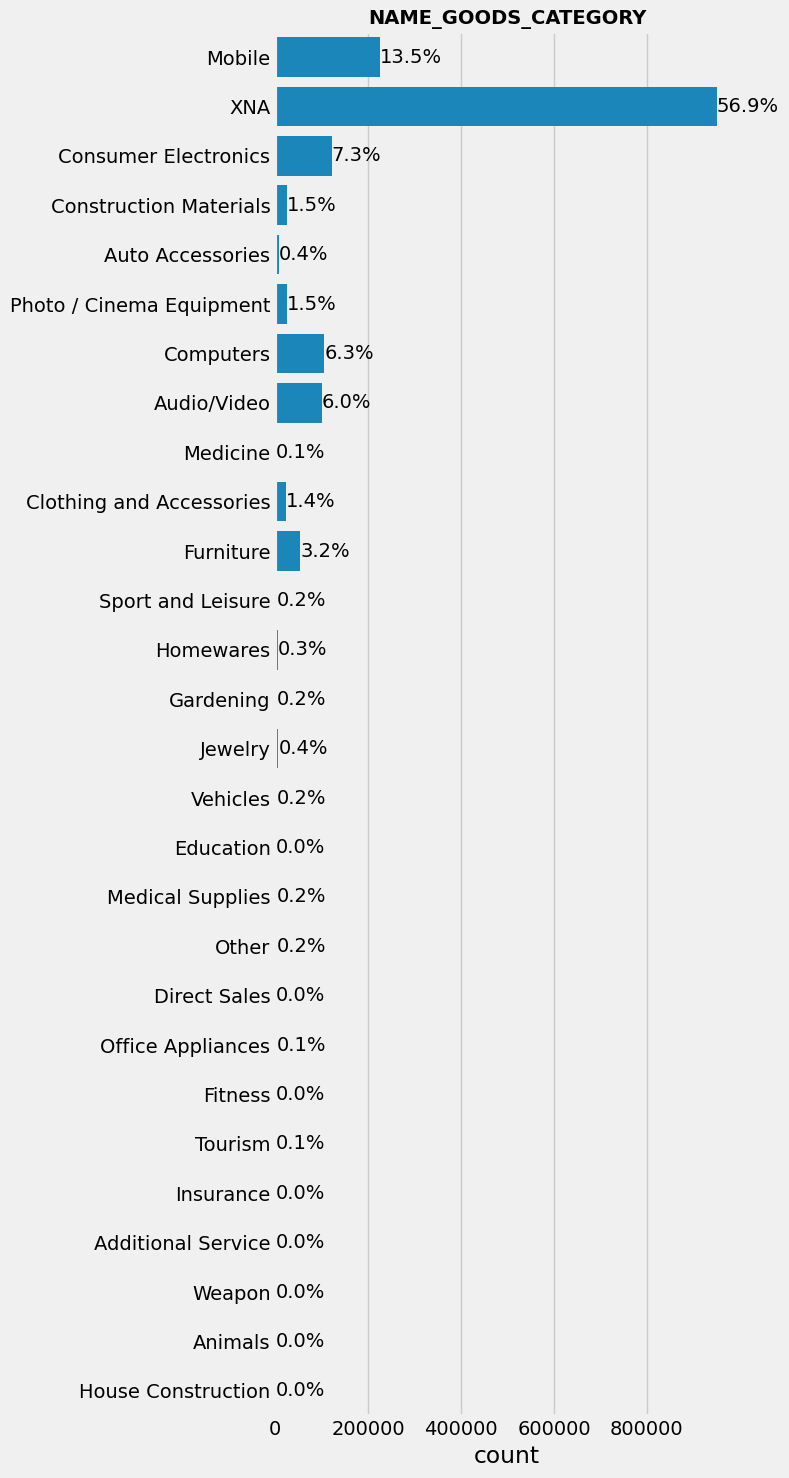

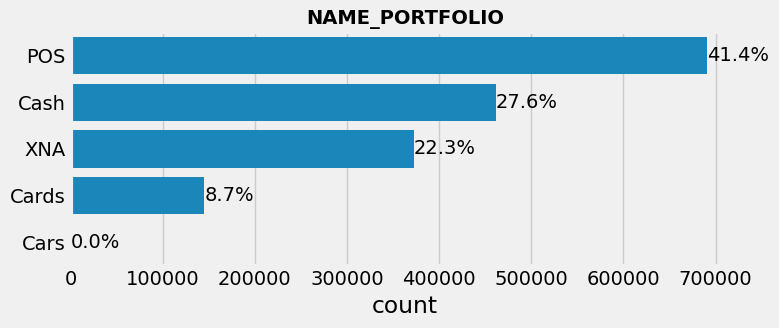

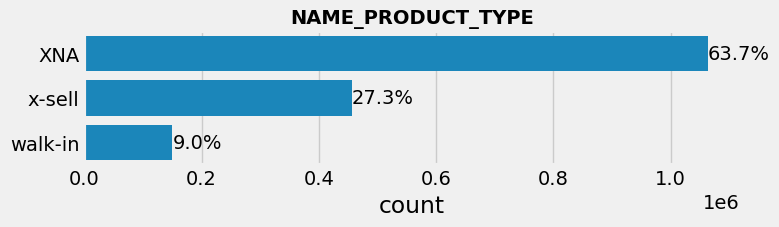

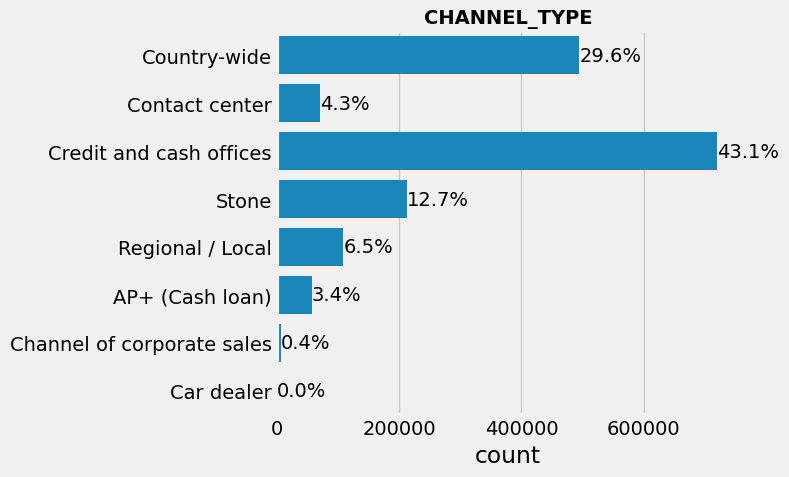

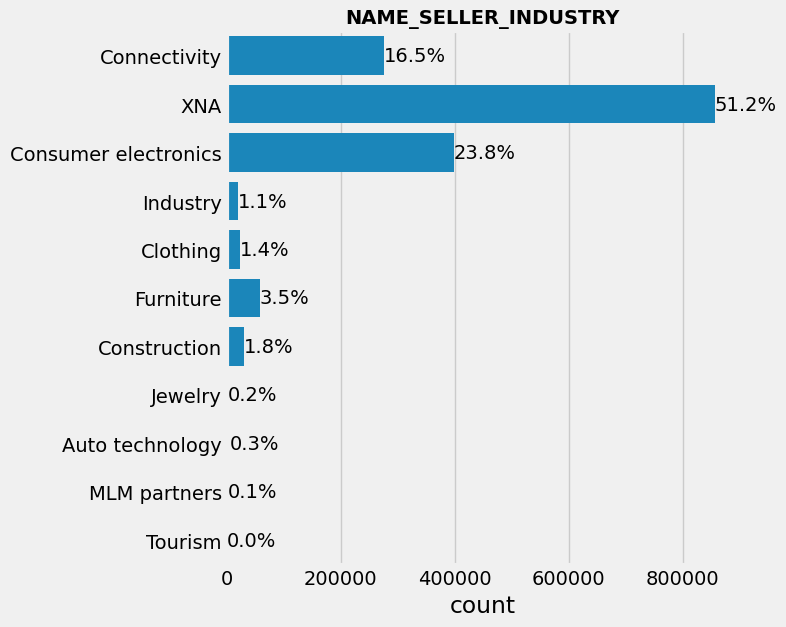

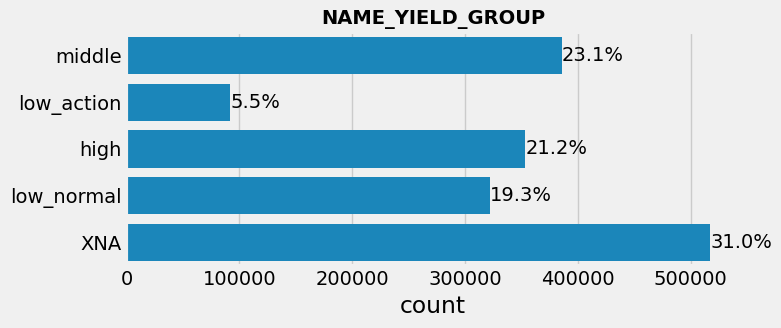

!Servere outliers detected. Total values: 1670214 original range: -1 - 4000000
Hiding outliers above 4551.5: 9025 values;


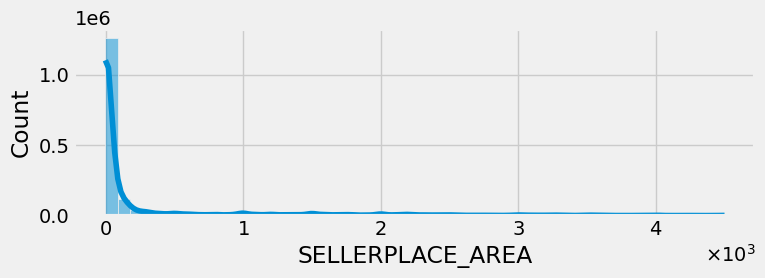

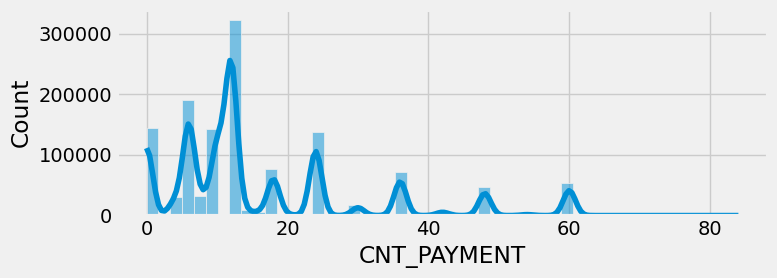

In [35]:
for col in ['NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'NAME_SELLER_INDUSTRY', 'NAME_YIELD_GROUP']:
    plot_categorical_dist(previous_application, col)

for col in ['SELLERPLACE_AREA', 'CNT_PAYMENT']:
    plot_numeric_dist(previous_application, col)

* Significant number of features that should yeald well for decision tree style analysis. **number of categorical featues would make manhatan distance in knn complex to define**.

#### Loan timeline and insurance

In [36]:
loan_timeline_insurance = [
    'PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
    'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL'
]

previous_application_dict['loan_timeline_insurance'] = loan_timeline_insurance
bool_columns.add('PRODUCT_COMBINATION')
num_columns.update(['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL'])

describer.describe(loan_timeline_insurance)

from tables:  ['previous_application']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
204,PRODUCT_COMBINATION,Detailed product combination of the previous application,NaN,346,17,object,"[POS mobile with interest, Cash X-Sell: low, Cash X-Sell: high]"
205,DAYS_FIRST_DRAWING,Relative to application date of current application when was the first disbursement of the previous application,time only relative to the application,673065,2838,float64,"[365243.0, -277.0, -265.0]"
206,DAYS_FIRST_DUE,Relative to application date of current application when was the first due supposed to be of the previous application,time only relative to the application,673065,2892,float64,"[-42.0, -134.0, -271.0]"
207,DAYS_LAST_DUE_1ST_VERSION,Relative to application date of current application when was the first due of the previous application,time only relative to the application,673065,4605,float64,"[300.0, 916.0, 59.0]"
208,DAYS_LAST_DUE,Relative to application date of current application when was the last due date of the previous application,time only relative to the application,673065,2873,float64,"[-42.0, 365243.0, -182.0]"
209,DAYS_TERMINATION,Relative to application date of current application when was the expected termination of the previous application,time only relative to the application,673065,2830,float64,"[-37.0, 365243.0, -177.0]"
210,NFLAG_INSURED_ON_APPROVAL,Did the client requested insurance during the previous application,NaN,673065,2,float64,"[0.0, 1.0]"


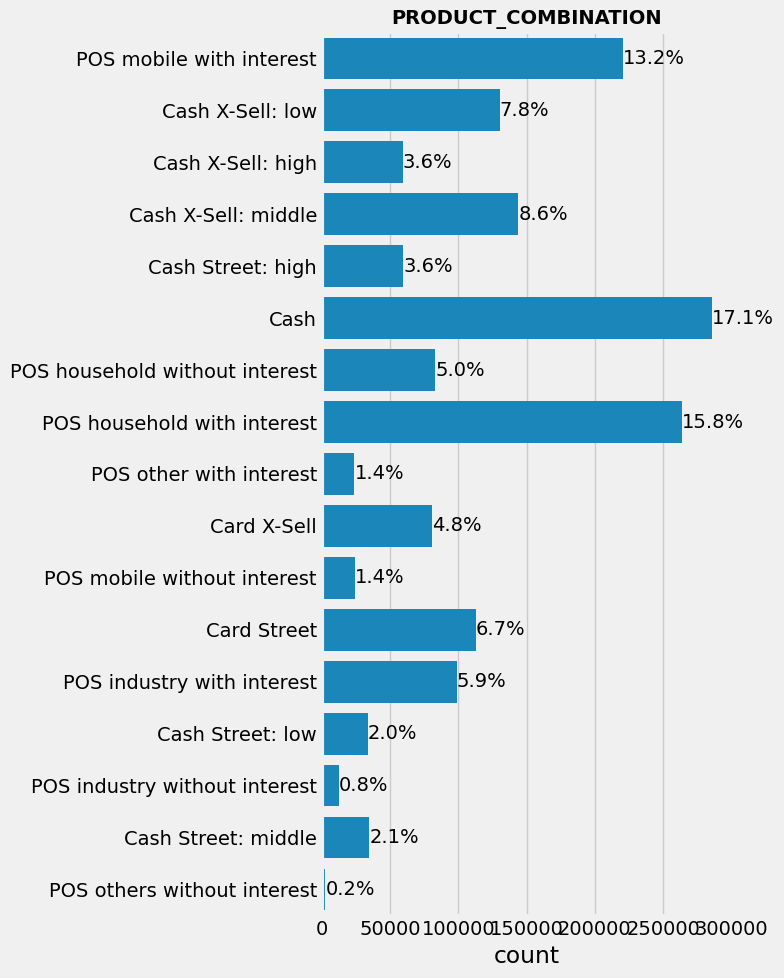

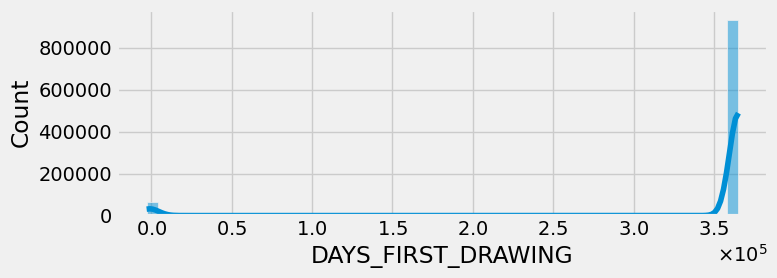

!Servere outliers detected. Total values: 1670214 original range: -2892.0 - 365243.0
Hiding outliers above 3792.0: 40645 values;


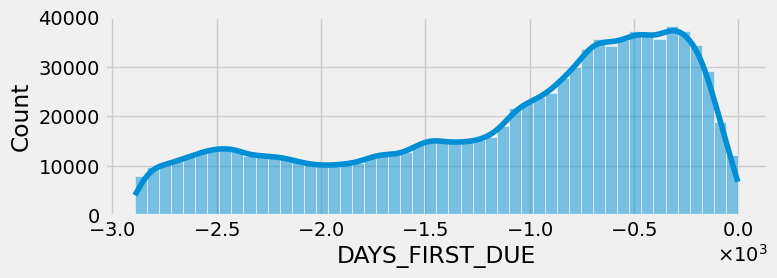

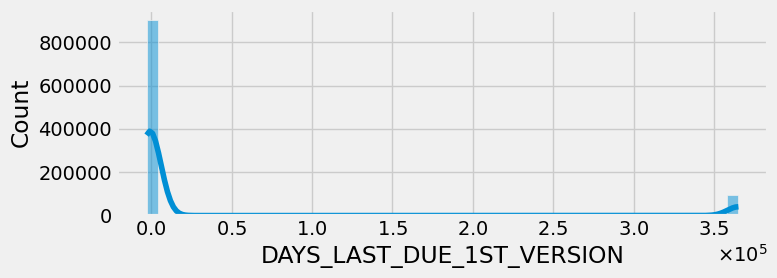

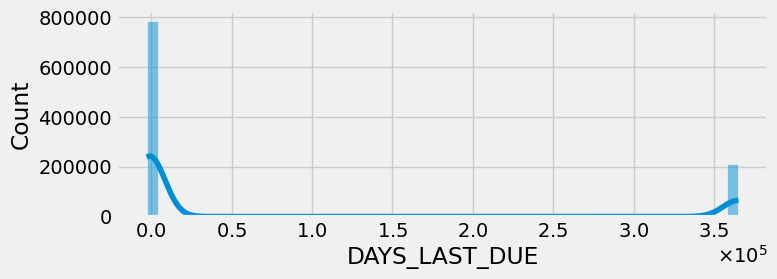

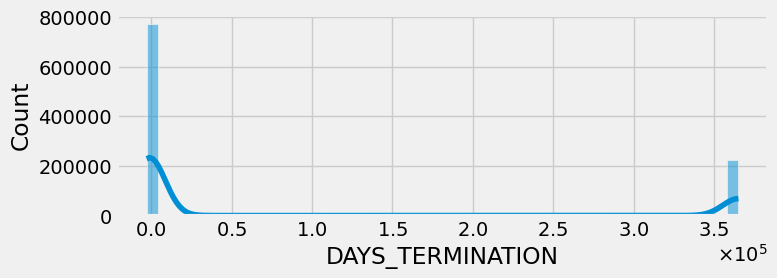

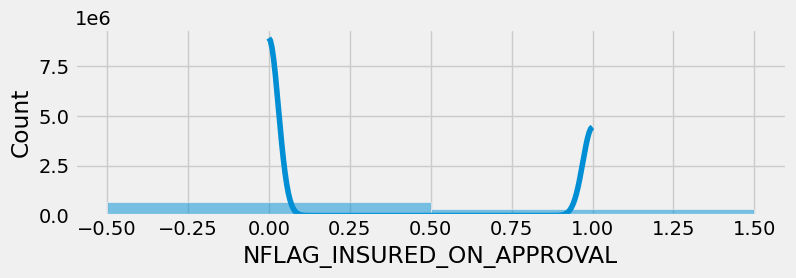

In [37]:
plot_categorical_dist(previous_application, 'PRODUCT_COMBINATION')

for col in ['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL']:
    plot_numeric_dist(previous_application, col)

## previous_application Conclusions

**Previous application data is too complex for non ML solution. High number of categoricals makes it unsuitable for KNN style classification**

In [38]:
tables_columns['previous_application'] = previous_application_dict

# installments_payments

In [39]:
installments_payments = tables['installments_payments']
describer = table_navigator.ColumnDescriber(tables, 'installments_payments')
display(installments_payments.shape)
installments_payments.info()

(13605401, 8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


**The intalments table is very narrow and long. It needs aggregation via model. The model should be able to generalize well, but due to few features might not be too informative**.

In [40]:
installments_payments_all = [
    'SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER',
    'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT'
]

tables_columns['installments_payments'] = installments_payments_all
id_variables.update(['SK_ID_PREV', 'SK_ID_CURR'])
num_columns.update(['NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT'])

describer.describe(installments_payments_all)

from tables:  ['installments_payments']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
212,SK_ID_CURR,ID of loan in our sample,hashed,0,339587,int64,"[161674, 151639, 193053]"
213,NUM_INSTALMENT_VERSION,Version of installment calendar (0 is for credit card) of previous credit. Change of installment version from month to month signifies that some parameter of payment calendar has changed,NaN,0,65,float64,"[1.0, 0.0, 2.0]"
214,NUM_INSTALMENT_NUMBER,On which installment we observe payment,NaN,0,277,int64,"[6, 34, 1]"
215,DAYS_INSTALMENT,When the installment of previous credit was supposed to be paid (relative to application date of current loan),time only relative to the application,0,2922,float64,"[-1180.0, -2156.0, -63.0]"
216,DAYS_ENTRY_PAYMENT,When was the installments of previous credit paid actually (relative to application date of current loan),time only relative to the application,2905,3039,float64,"[-1187.0, -2156.0, -63.0]"
217,AMT_INSTALMENT,What was the prescribed installment amount of previous credit on this installment,NaN,0,902539,float64,"[6948.36, 1716.525, 25425.0]"
218,AMT_PAYMENT,What the client actually paid on previous credit on this installment,NaN,2905,944235,float64,"[6948.36, 1716.525, 25425.0]"


In [41]:
installments_payments.loc[installments_payments['AMT_PAYMENT'].isna(), :]

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
3764207,1531600,103793,1.0,7,-668.0,NaN,49741.020,NaN
3764208,1947105,159974,1.0,24,-36.0,NaN,22849.515,NaN
3764209,1843773,167270,1.0,22,-20.0,NaN,48092.355,NaN
3764210,1691592,192536,1.0,5,-2561.0,NaN,7675.425,NaN
3764211,1531299,157088,0.0,11,-1847.0,NaN,67.500,NaN
...,...,...,...,...,...,...,...,...
13605396,2186857,428057,0.0,66,-1624.0,NaN,67.500,NaN
13605397,1310347,414406,0.0,47,-1539.0,NaN,67.500,NaN
13605398,1308766,402199,0.0,43,-7.0,NaN,43737.435,NaN
13605399,1062206,409297,0.0,43,-1986.0,NaN,67.500,NaN


* The few missing values likely include installments that have not been paid yet.

!Servere outliers detected. Total values: 13605401 original range: 0.0 - 178.0
Hiding outliers above 5.0: 76875 values;


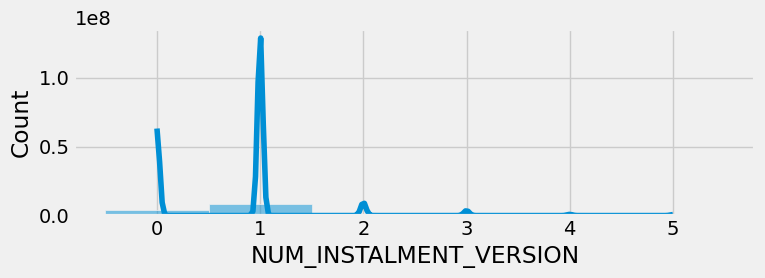

!Servere outliers detected. Total values: 13605401 original range: 1 - 277
Hiding outliers above 203.5: 1529 values;


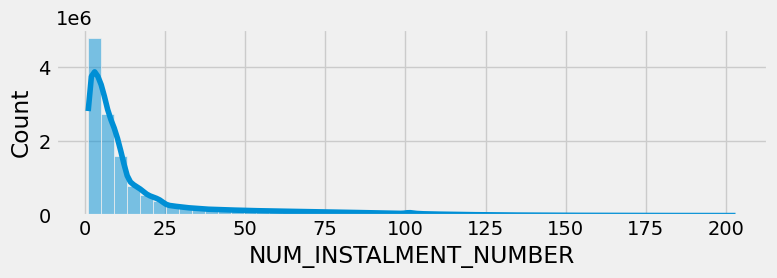

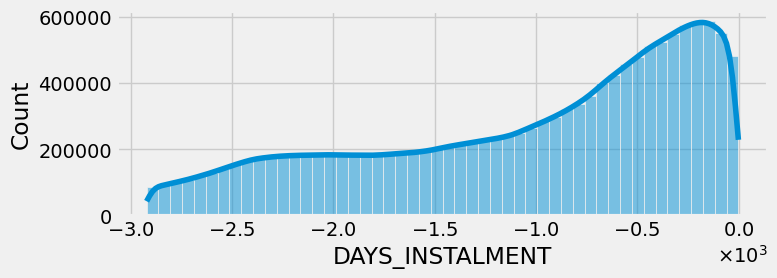

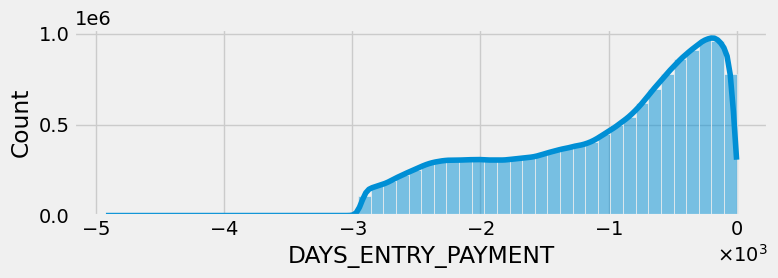

!Servere outliers detected. Total values: 13605401 original range: 0.0 - 3771487.845
Hiding outliers above 117321.12: 169512 values;


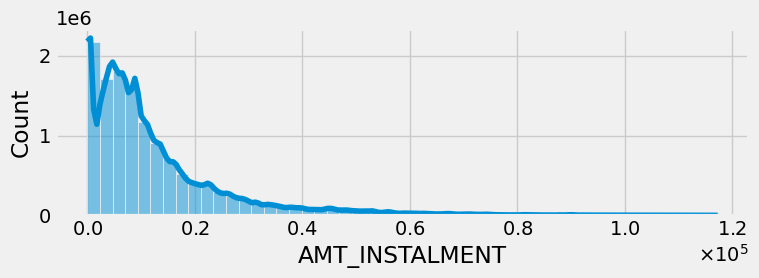

!Servere outliers detected. Total values: 13605401 original range: 0.0 - 3771487.845
Hiding outliers above 119162.97000000002: 196739 values;


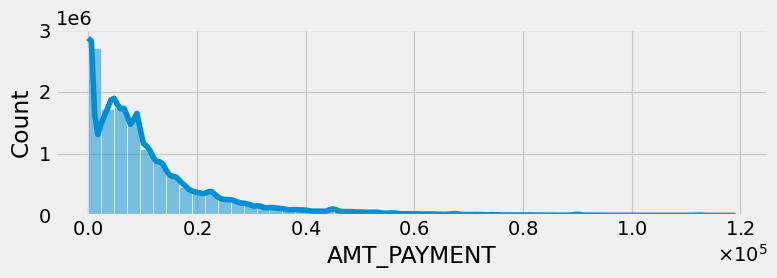

In [42]:
for col in ['NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']:
    plot_numeric_dist(installments_payments, col)

## installments_payments Conclusions

* **Installment payments provide a lot of information for single individuals and need to be aggregated.**

## Summary

In [43]:
str_columns.update(['SK_ID_PREV', 'SK_ID_CURR', 'SK_ID_BUREAU'])

for folder in ["data/processed", "models"]:
    with open(os.path.join(folder, "supplementary_tables_columns.pkl"), "wb") as f:
        pkl.dump({
            'tables_columns': tables_columns,
            'id_variables': id_variables,
            'cat_columns': cat_columns,
            'num_columns': num_columns,
            'str_columns': str_columns,
            'bool_columns': bool_columns
        }, f)


## Model suggestions

```Each of the supplementary tables provides multiple datapoints for each individual. Consequently, either simple aggregation techniques, or a model abble to aggregate "layers" of information are needed for an interpretable solution. One obvious solution is to use usupervised learning techniques to aggregate data data into manageable chunks/types.```

# Supplementary Tables Actionables
Key insights derived during data cleaning and investigation are listed here. Action is taken in further notebooks.

### Bureau
#### Feature Engineering Requirements
- **Aggregation techniques will be required to engineer useful features from the bureau** - due to multiple records per individual
- **Missing values for `AMT_CREDIT_SUM_LIMIT`, `AMT_CREDIT_SUM` should be treated differently to NaNs** - likely represent people who never took Credit Bureau credit
- **For `CREDIT_ACTIVE`, `CREDIT_CURRENCY`, `CREDIT_TYPE` majority of groups are too infrequent to be truly meaningful** - consider grouping rare categories
- Affected columns: `CREDIT_ACTIVE`, `CREDIT_CURRENCY`, `CREDIT_TYPE`, `AMT_CREDIT_SUM`, `AMT_CREDIT_SUM_LIMIT`, `AMT_ANNUITY`, `AMT_CREDIT_SUM_DEBT`, `CREDIT_DAY_OVERDUE`, `AMT_CREDIT_MAX_OVERDUE`, `AMT_CREDIT_SUM_OVERDUE`, `DAYS_CREDIT`, `DAYS_CREDIT_ENDDATE`, `DAYS_ENDDATE_FACT`, `DAYS_CREDIT_UPDATE`

#### Data Quality Issues
- **Significant portion of overdue information is missing** - likely people without credit history
- **Significant portion of end dates are missing** - likely people who never took out credit are treated as NaN
- **Positive and negative credit can be owned (overpaying)** - majority of people have a credit balance of 0

### Bureau Balance
#### Feature Engineering Requirements  
- **The bureau table stores encoded evaluation of monthly balance** - significant potential for feature engineering
- **Aggregation will be required for final model, for each individual** - data is very narrow and very long
- Affected columns: `SK_ID_BUREAU`, `MONTHS_BALANCE`, `STATUS`

### POS_CASH_balance
#### Feature Engineering Requirements
- **Monthly balance snapshots require aggregation techniques** - multiple records per individual
- Affected columns: `SK_ID_PREV`, `SK_ID_CURR`, `MONTHS_BALANCE`, `CNT_INSTALMENT`, `CNT_INSTALMENT_FUTURE`, `NAME_CONTRACT_STATUS`, `SK_DPD`, `SK_DPD_DEF`

### Credit Card Balance
#### Feature Engineering Requirements
- **Credit card balance provides data that is both wide and longer than applications table** - prime target for unsupervised learning style feature engineering
- **0 values dominate the balance values, with significant variables** - linear